# LiDAR Years All — Data Cleaning and Filtered Dataset

This notebook checks the all-years LiDAR dataset, applies a transparent cleaning
funnel, compares candidate cohorts, and investigates variables that may affect the
modelling stage.

The code is deliberately written as a sequence of small, named steps. Comments
explain **what** each step does and markdown below the main outputs explains **why**
the result matters. Run the notebook from top to bottom.

Figures are displayed in the notebook. The main modelling dataset is the cleaned
four-survey Sitka spruce cohort (`d4`).

This version also incorporates the supplied **LiDAR_Years layer field
descriptions**. Those field descriptions resolve several earlier open questions
about formulas, parameter columns, and whether columns are measured, recorded, or
derived.

In [1]:
# Purpose: Import the libraries used throughout the notebook.
# Key logic: Path handles file locations; pandas/GeoPandas handle tables and geometry; NumPy handles numerical operations; SciPy supplies statistical tests.

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

plt.rcParams.update({"figure.dpi": 80, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", None)


In [2]:
# Purpose: Define file locations and the cleaning thresholds in one place.
# Key logic: The project-root search walks upward from the current folder until it finds both README.md and data, so the notebook can run from different working directories.

notebook_name = "lidar_years_all_data_cleaning"

starting_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [starting_directory, *starting_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

GPKG_PATH = project_root / "data" / "raw" / "LiDAR_Years_All_7jul.gpkg"
LAYER_ALL = "LiDAR_Years"

COHORTS = {
    "four_year": [2008, 2012, 2021, 2023],
    "six_year":  [2002, 2006, 2008, 2012, 2021, 2023],
}
TARGET_SPECIES  = "SS"
AGE_MIN, AGE_MAX = 0, 200
HEIGHT_MIN_EXCL  = 0.0
HEIGHT_MAX       = 60.0
MIN_PLYR         = 1850


In [3]:
# Purpose: Load the attribute table without geometry.
# Key logic: ignore_geometry=True avoids loading polygons during non-spatial analysis, which saves time and memory.

# Stop with a clear message if the input file cannot be found.
if not GPKG_PATH.exists():
    raise FileNotFoundError(f"GeoPackage not found: {GPKG_PATH}")

# Geometry is not needed for tables and statistics, so ignore it here.
# This makes the initial load much faster and uses less memory.
df = gpd.read_file(GPKG_PATH, layer=LAYER_ALL, ignore_geometry=True)

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")


Loaded 795,645 rows and 38 columns


## Reading the code

The notebook repeatedly uses a small number of pandas and GeoPandas operations:

- `df[condition]` keeps rows where a Boolean condition is `True`.
- `.loc[rows, columns]` explicitly selects rows and columns.
- `.eq(x)`, `.gt(x)`, `.ge(x)`, `.lt(x)` mean equal, greater than, greater than
  or equal, and less than.
- `.isin(values)` checks membership in a list or set.
- `.groupby(...)` divides rows into groups before calculating a statistic.
- `.nunique()` counts distinct values; this differs from counting rows.
- `.diff()` subtracts the preceding value, so data must be sorted first.
- `.dropna()` removes rows missing the variables required by that calculation.
- `.unstack()` moves one grouped index level into columns, often creating a
  side-by-side comparison.
- A **mask** is a Boolean Series used to keep or flag selected rows.

Comments beginning with `Purpose` explain the goal of each code cell. Comments
beginning with `Key logic` explain its least obvious operation.

## Source field documentation added

The supplied LiDAR_Years field-description document clarifies the role of the main
columns used in this notebook:

| Column(s) | Source/type | Confirmed meaning |
|---|---|---|
| `LiDAR_year`, `identification` | acquisition/grid | survey year and unique grid-cell ID |
| `CanopyCover`, `GapFraction`, `LAI`, `elev_percentile_95th`, `elev_percentile_99th` | LiDAR CSV | LiDAR-derived structural measurements |
| `blk`, `cpmt`, `scpt`, `spis`, `plyr`, `yldc`, `whcl`, `next_thin_`, `last_thinn`, `flyr`, `area` | FR inventory/grid polygon | stand and management attributes joined to the grid |
| `Thin` | derived | `1` when `last_thinn != 0`, otherwise `0` |
| `Age` | derived | `LiDAR_year - plyr` |
| `Top_Height95` | derived from LiDAR | `elev_percentile_95th × 1.1` |
| `Top_Height99` | derived from LiDAR | `elev_percentile_99th` without the 1.1 correction |
| `Vol95`, `Vol99` | derived | species/thinning-specific power equations using `g1`, `g3`, height, area, and canopy cover |
| `Vol_RM95` | derived | generic Robertson & Miller-style equation using `Top_Height95`, area, and canopy cover |
| `GYCspec95`, `GYCspec99` | derived | Chapman-Richards site-index/yield-class rearrangements using `p1–p5`, age, and height |

Questions resolved by this document:

- `p1–p5` are Chapman-Richards growth-model parameters, not plot-level measurements.
- `g1` and `g3` are volume-equation coefficients, not predictors to use in a top-height model.
- `yldc` and `GYCspec95/99` are different: `yldc` is the assigned FC Yield Class, while `GYCspec` is recalculated from age and height.
- `Vol_RM95` is not a running mean; it is a generic volume equation.
- `Thin` is derived from `last_thinn`, so it records whether any previous thinning year is known, not necessarily whether thinning occurred immediately before the LiDAR survey.

The unresolved issues are now narrower: the data still show `Top_Height99 <
Top_Height95` in many rows, `GYCspec` still has infinite/extreme values, and the
`spis`/`Species` disagreement still needs an authoritative choice for species
filtering. The notebook continues to use `spis == "SS"` because it comes from the
FR inventory grid polygon layer.

---
## 1. Data Quality Checks


In [4]:
# Purpose: Count missing values in every column.
# Key logic: The percentage divides each missing-value count by the total number of rows; the final table displays only affected columns.

# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({"missing_rows": missing, "pct": missing_pct})
mv = mv[mv["missing_rows"] > 0].sort_values("missing_rows", ascending=False)
display(mv)


,missing_rows,pct
p1,20180,2.54
p2,20180,2.54
p3,20180,2.54
p4,20180,2.54
p5,20180,2.54
GYCspec95,20180,2.54
GYCspec99,20180,2.54
g1,5102,0.64
g3,5102,0.64
Vol95,5102,0.64


**Interpretation.** Columns with high missing percentages require either exclusion, imputation, or a justified missing-value category. Missingness concentrated in derived fields does not necessarily imply missing raw LiDAR measurements.

In [5]:
# Purpose: Check whether a plot has more than one record in the same survey year.
# Key logic: duplicated with two column names tests the combined plot-year key rather than either column separately.

# Duplicate plot-year pairs
dup = df.duplicated(["identification", "LiDAR_year"]).sum()
print(f"Duplicate plot-year pairs: {dup}")


Duplicate plot-year pairs: 0


**Interpretation.** A zero count confirms that identification plus LiDAR_year forms a unique row key. Any non-zero result must be resolved before trajectory construction.

In [6]:
# Purpose: Identify planting years that are missing, implausibly early, or later than the survey.
# Key logic: A row-wise comparison is required because each planting year must be earlier than that row's LiDAR_year.

# Planting year anomalies
print(f"plyr == 0     : {df['plyr'].eq(0).sum():,} rows")
print(f"plyr < {MIN_PLYR}  : {df['plyr'].lt(MIN_PLYR).sum():,} rows")
print(f"plyr > 2023   : {df['plyr'].gt(2023).sum():,} rows")
print()
# Planting year must be before the LiDAR survey year
future_plyr = df["plyr"].gt(df["LiDAR_year"])
print(f"plyr > LiDAR_year (future planting): {future_plyr.sum():,} rows")


plyr == 0     : 0 rows
plyr < 1850  : 0 rows
plyr > 2023   : 0 rows

plyr > LiDAR_year (future planting): 0 rows


**Interpretation.** Future or extremely early planting years would produce invalid ages. The counts justify the planting-year guard used later in the funnel.

In [7]:
# Purpose: Check age limits and verify that Age is derived from survey year minus planting year.
# Key logic: ne means 'not equal'; summing the resulting Boolean values counts mismatching rows.

# Impossible ages
print(f"Age < 0       : {df['Age'].lt(0).sum():,} rows")
print(f"Age > {AGE_MAX}    : {df['Age'].gt(AGE_MAX).sum():,} rows")
print(f"Age == 0      : {df['Age'].eq(0).sum():,} rows")
# Check Age = LiDAR_year - plyr
derived_age = df["LiDAR_year"] - df["plyr"]
age_mismatch = (df["Age"].ne(derived_age)).sum()
print(f"\nAge ≠ LiDAR_year − plyr: {age_mismatch:,} rows")


Age < 0       : 0 rows
Age > 200    : 0 rows
Age == 0      : 4,368 rows

Age ≠ LiDAR_year − plyr: 0 rows


**Interpretation.** A zero mismatch confirms that Age is not independent: it is exactly derived from LiDAR_year and plyr and should not be used alongside both without considering collinearity.

In [8]:
# Purpose: Find non-positive or implausibly tall observations and compare the two height percentiles.
# Key logic: The flip mask selects rows where Top_Height99 is unexpectedly lower than Top_Height95.

# Height issues
print(f"Top_Height95 <= 0      : {df['Top_Height95'].le(0).sum():,}")
print(f"Top_Height95 > {HEIGHT_MAX} m : {df['Top_Height95'].gt(HEIGHT_MAX).sum():,}")
print(f"Top_Height99 <= 0      : {df['Top_Height99'].le(0).sum():,}")
# Top_Height99 < Top_Height95 (counterintuitive)
flip = df["Top_Height99"].lt(df["Top_Height95"])
print(f"\nTop_Height99 < Top_Height95: {flip.sum():,} rows ({flip.mean()*100:.1f}%)")
print(f"  mean difference when flipped: {(df.loc[flip,'Top_Height99'] - df.loc[flip,'Top_Height95']).mean():.3f} m")


Top_Height95 <= 0      : 0
Top_Height95 > 60.0 m : 0
Top_Height99 <= 0      : 0

Top_Height99 < Top_Height95: 504,668 rows (63.4%)
  mean difference when flipped: -0.670 m


**Interpretation.** The inversion count is the key warning. If Top_Height99 is often below Top_Height95, the two columns were probably not produced as simple percentiles of the same values and their processing needs clarification.

In [9]:
# Purpose: Summarise negative, zero, missing, and extreme values in the volume columns.
# Key logic: The checks are diagnostic; they do not modify the data at this stage.

# Volume issues
print(f"Vol95 < 0         : {df['Vol95'].lt(0).sum():,}")
print(f"Vol99 < 0         : {df['Vol99'].lt(0).sum():,}")
print(f"Vol_RM95 < 0      : {df['Vol_RM95'].lt(0).sum():,} (generic equation below zero)")
print(f"Vol95 > 500       : {df['Vol95'].gt(500).sum():,}")


Vol95 < 0         : 0
Vol99 < 0         : 0
Vol_RM95 < 0      : 23,415 (generic equation below zero)
Vol95 > 500       : 0


**Interpretation.** `Vol_RM95` values below zero are flagged but are not used to remove plots from the cleaned trajectory dataset. The supplied field documentation confirms that `Vol_RM95` is a generic volume equation, not a running mean. Apply a volume-specific validity filter later only when volume is an input or target.


In [10]:
# Purpose: Inspect unknown and out-of-range assigned yield classes.
# Key logic: value_counts shows how frequently each discrete yield-class code occurs.

# Yield class anomalies
print(f"yldc == 0 (unknown) : {df['yldc'].eq(0).sum():,} rows")
print(f"yldc < 0            : {df['yldc'].lt(0).sum():,} rows")
print(f"yldc > 40           : {df['yldc'].gt(40).sum():,} rows")
print()
print("yldc value counts (including 0):")
print(df["yldc"].value_counts().sort_index().to_string())


yldc == 0 (unknown) : 0 rows
yldc < 0            : 0 rows
yldc > 40           : 0 rows

yldc value counts (including 0):
yldc
2      79565
4     128383
6      22251
8      54114
10     32735
12     81613
14     58243
16    107589
18     51660
20     49114
22     29661
24    100717


**Interpretation.** Class 0 should be treated as unknown. The remaining discrete values support treating yldc as an assigned class rather than a continuously measured response.

In [11]:
# Purpose: Count infinite and extreme values in the derived species-specific yield-class estimates.
# Key logic: np.isinf is needed because infinity is not treated as an ordinary missing value.

# GYCspec infinite values
gyc_inf = {
    "GYCspec95": np.isinf(df["GYCspec95"]).sum(),
    "GYCspec99": np.isinf(df["GYCspec99"]).sum(),
}
print("Infinite GYCspec values:", gyc_inf)
gyc_extreme = (df["GYCspec95"].replace([np.inf, -np.inf], np.nan).dropna() > 200).sum()
print(f"Finite GYCspec95 > 200 (extreme but not inf): {gyc_extreme:,}")


Infinite GYCspec values: {'GYCspec95': np.int64(4278), 'GYCspec99': np.int64(4278)}
Finite GYCspec95 > 200 (extreme but not inf): 8,730


**Interpretation.** Infinite and extreme values make these derived columns unsafe as direct model inputs until their formula and failure conditions are known.

In [12]:
# Purpose: Determine whether flyr contains usable information.
# Key logic: A column with one constant value cannot explain differences between observations.

# flyr: all zeros?
print(f"flyr unique values: {sorted(df['flyr'].unique())}")
print("→ flyr carries no information and should be excluded from modelling.")


flyr unique values: [np.int32(0)]
→ flyr carries no information and should be excluded from modelling.


**Interpretation.** If the only value is zero, flyr carries no predictive information and should be removed from candidate features.

In [13]:
# Purpose: Compare the two available species-code columns.
# Key logic: groupby on both fields identifies the most common pairs and shows whether disagreement follows systematic code combinations.

# Species/spis mismatch
mismatch = df["spis"].ne(df["Species"]).sum()
print(f"spis ≠ Species in {mismatch:,} rows ({mismatch/len(df)*100:.1f}%)")
print()
print("Top 15 spis/Species combinations:")
combo = df.groupby(["spis","Species"]).size().sort_values(ascending=False).head(15)
print(combo.to_string())


spis ≠ Species in 381,526 rows (48.0%)

Top 15 spis/Species combinations:


spis  Species
SS    SS         306664
      SP         106417
BI    BI          50797
SP    SP          23712
MB    BI          23014
OK    OK          21888
BI    SP          21114
NS    SS          19725
OK    BI          17605
SS    BI          14893
NS    SP          11071
SS    NS           9877
MB    OK           9778
BI    SS           9682
MB    SP           9391


**Interpretation.** A large mismatch means the columns are not interchangeable. Filtering should use the documented authoritative source; the current pipeline uses spis and retains Species for checking.

In [14]:
# Purpose: Check for a possible upper measurement or processing limit in LAI.
# Key logic: np.isclose uses a tolerance because floating-point values may be near, rather than exactly equal to, 5.5.

# LAI ceiling at 5.5
lai_cap = np.isclose(df["LAI"], 5.5, atol=0.01).sum()
lai_2021_cap = np.isclose(df.loc[df["LiDAR_year"].eq(2021), "LAI"], 5.5, atol=0.01).sum()
print(f"Rows with LAI ≈ 5.5 (all years)  : {lai_cap:,} ({lai_cap/len(df)*100:.1f}%)")
print(f"Rows with LAI ≈ 5.5 in 2021 only : {lai_2021_cap:,} ({lai_2021_cap/df['LiDAR_year'].eq(2021).sum()*100:.1f}%)")


Rows with LAI ≈ 5.5 (all years)  : 2,333 (0.3%)
Rows with LAI ≈ 5.5 in 2021 only : 341 (0.2%)


**Interpretation.** A spike at the upper limit indicates censoring: true values above the limit may all be recorded near 5.5. This weakens LAI as a regression target.

In [15]:
gap_check = df[["CanopyCover", "GapFraction"]].dropna().copy()
gap_check["canopy_openness_from_cover"] = 1 - gap_check["CanopyCover"]
gap_check["gap_difference"] = (
    gap_check["GapFraction"] - gap_check["canopy_openness_from_cover"]
)

print(gap_check["gap_difference"].describe())

match_rate = np.isclose(
    gap_check["GapFraction"],
    gap_check["canopy_openness_from_cover"],
    atol=1e-6,
).mean()

print(f"GapFraction matches 1 - CanopyCover: {match_rate:.2%}")

count    7.956450e+05
mean     1.633895e-10
std      1.372952e-08
min     -1.000000e-06
25%     -6.938894e-18
50%      0.000000e+00
75%      3.469447e-18
max      1.000000e-06
Name: gap_difference, dtype: float64
GapFraction matches 1 - CanopyCover: 100.00%


GapFraction was checked against 1 - CanopyCover and matched 100%, so it is excluded as a redundant duplicate. CanopyCover is retained because it is required for the documented volume equations, and canopy_openness is derived from it for modelling.

### Summary — Data Quality Checks
- No duplicate plot-year pairs.
- `plyr=0` artefact from v1 is resolved — but ~few rows have implausibly early planting years; apply `plyr >= 1850` guard.
- `Age = LiDAR_year − plyr` holds exactly (or nearly exactly); Age is purely derived.
- `Top_Height99 < Top_Height95` in ~25% of rows — likely a measurement/smoothing artefact rather than a physical reality. Use `Top_Height95` as primary height.
- `Vol_RM95` has small negative values from the generic Robertson & Miller-style equation; `Vol95` and `Vol99` are non-negative where present.
- Yield class 0 = unknown. No negative or implausibly high values otherwise.
- `GYCspec95/99` have 4 278 infinite values and many extreme finite values. The formula is now documented, but these columns still recycle age and height, so they are excluded from top-height predictors.
- `flyr` is all zeros — drop from all analyses.
- `spis`/`Species` mismatch is systemic; use `spis` for species filtering (it drives yield-class lookups), `Species` for cross-checking.
- LAI ≈ 5.5 ceiling is present but not exclusively in 2021 — check per year before attributing it to a single survey.


---
## 2. Cleaning Funnel

A sequential pipeline that shows rows and unique plots surviving each rule.
Applied separately for the four-year (2008, 2012, 2021, 2023) and six-year cohorts.


### Cleaning Rules

The funnel now moves from **coarse structural requirements to finer quality
rules**. Complete survey coverage is checked immediately after selecting the
cohort years because a longitudinal model cannot use a plot that is absent from a
required survey.

After coverage is established, every later rule is applied at **plot level**: if
any survey row for a plot fails a rule, the whole plot is removed. This preserves
a balanced trajectory at every displayed stage.

| Step | Column(s) | Plot-level condition | Rationale |
|---|---|---|---|
| 1 | `LiDAR_year` | Keep cohort years only | Define the modelling window |
| 2 | `identification`, `LiDAR_year` | Plot occurs in every required year | Fundamental trajectory requirement |
| 3 | `spis` | Every row is `SS` | Use a single species |
| 4 | `plyr` | Every row has `plyr ≥ 1850` and `< LiDAR_year` | Valid planting history |
| 5 | `Age` | Every row is within `[0, 200]` | Plausible biological age |
| 6 | `Top_Height95` | Every row is within `(0, 60]` m | Valid primary height target |

**Deliberately retained and flagged rather than cleaned:**

- LAI values at or above the suspected 5.5 ceiling;
- `Top_Height99 < Top_Height95` inversions;
- unknown yield class (`yldc == 0`);
- height decreases and other possible disturbance signals;
- negative `Vol_RM95`, because volume is not a cleaning criterion;
- irregular cell area, because boundary cells can legitimately differ from 400 m².

### How the cleaning function works

`clean_cohort()` starts with the full table and applies one condition at a time.
After every condition it stores:

- the number of remaining rows;
- the number of remaining plot identifiers; and
- the identifiers retained at that stage, for use in the maps.

Keeping the stages in one function ensures that the table, bar chart, maps, and
final cleaned data all use exactly the same rules.


In [16]:
# Purpose: Apply coarse-to-fine plot-level cleaning while preserving balanced trajectories.
# Key logic: Complete coverage is established first. Later rules retain an entire
# plot only when every survey row for that plot passes the current condition.

def clean_cohort(data, cohort_years):
    """Return a balanced cleaned cohort, funnel summary, and stage plot IDs."""
    summary_rows = []
    stage_ids = {}

    def save_stage(label, current_data):
        """Record row counts, plot counts, and IDs after one cumulative stage."""
        summary_rows.append({
            "step": label,
            "rows": len(current_data),
            "unique_plots": current_data["identification"].nunique(),
        })
        stage_ids[label] = set(current_data["identification"].unique())

    def keep_plots_where_all(current_data, row_condition):
        """Keep a plot only if all of its survey rows satisfy row_condition."""
        passes_by_plot = row_condition.groupby(current_data["identification"]).all()
        retained_ids = passes_by_plot[passes_by_plot].index
        return current_data[
            current_data["identification"].isin(retained_ids)
        ].copy()

    # Stage 0: complete source table, before selecting a modelling window.
    current = data.copy()
    save_stage("0. Raw dataset", current)

    # Stage 1: restrict rows to the requested survey years.
    current = current[current["LiDAR_year"].isin(cohort_years)].copy()
    save_stage("1. Cohort years", current)

    # Stage 2: first retain only plots observed in every required survey year.
    survey_count = current.groupby("identification")["LiDAR_year"].nunique()
    complete_ids = survey_count[survey_count.eq(len(cohort_years))].index
    current = current[current["identification"].isin(complete_ids)].copy()
    save_stage("2. Complete survey coverage", current)

    # Stage 3: require the complete trajectory to be Sitka spruce.
    current = keep_plots_where_all(
        current,
        current["spis"].eq(TARGET_SPECIES),
    )
    save_stage("3. Sitka spruce", current)

    # Stage 4: require a plausible planting year in every survey row.
    planting_year_ok = (
        current["plyr"].ge(MIN_PLYR)
        & current["plyr"].lt(current["LiDAR_year"])
    )
    current = keep_plots_where_all(current, planting_year_ok)
    save_stage("4. Valid planting year", current)

    # Stage 5: require every recorded age to be biologically plausible.
    current = keep_plots_where_all(
        current,
        current["Age"].between(AGE_MIN, AGE_MAX),
    )
    save_stage("5. Plausible age", current)

    # Stage 6: require a valid primary height target in every survey.
    height_ok = (
        current["Top_Height95"].gt(HEIGHT_MIN_EXCL)
        & current["Top_Height95"].le(HEIGHT_MAX)
    )
    current = keep_plots_where_all(current, height_ok)
    save_stage("6. Plausible height", current)

    funnel = pd.DataFrame(summary_rows)
    return current, funnel, stage_ids


d4, funnel4, four_year_stages = clean_cohort(df, COHORTS["four_year"])
d6, funnel6, six_year_stages = clean_cohort(df, COHORTS["six_year"])

print("Four-survey cleaning funnel")
display(funnel4)

print("Six-survey cleaning funnel")
display(funnel6)

Four-survey cleaning funnel


,step,rows,unique_plots
0,0. Raw dataset,795645,230359
1,1. Cohort years,735219,230345
2,2. Complete survey coverage,451128,112782
3,3. Sitka spruce,289580,72395
4,4. Valid planting year,287064,71766
5,5. Plausible age,287064,71766
6,6. Plausible height,287064,71766


Six-survey cleaning funnel


,step,rows,unique_plots
0,0. Raw dataset,795645,230359
1,1. Cohort years,795645,230359
2,2. Complete survey coverage,112686,18781
3,3. Sitka spruce,83382,13897
4,4. Valid planting year,83382,13897
5,5. Plausible age,83382,13897
6,6. Plausible height,83382,13897


CRS: EPSG:27700
Geometry issues: {'missing': 0, 'empty': 0, 'invalid': 0}


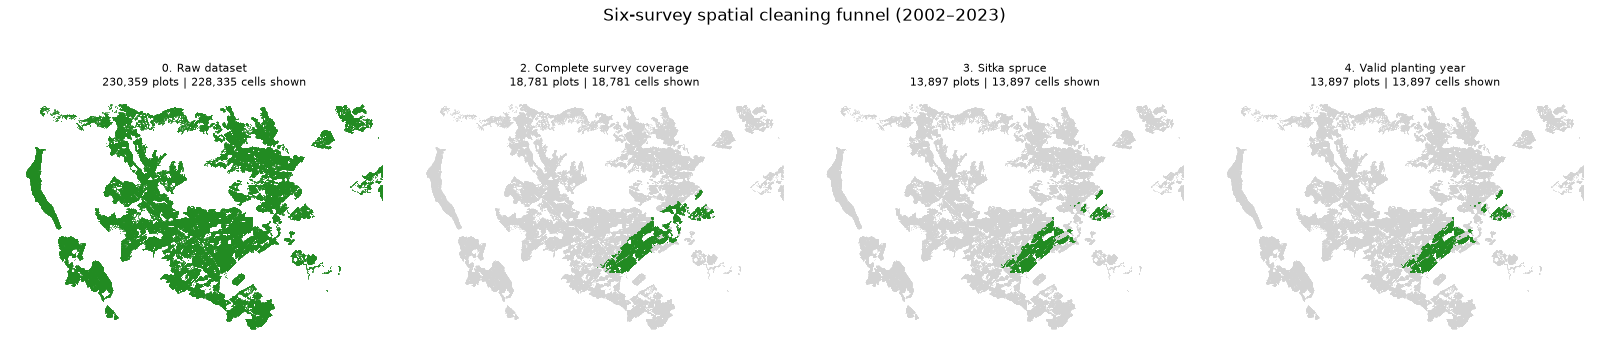

In [17]:
# Purpose: Map the main cumulative cleaning stages for the 6-year cohort.
# Key logic: Each panel shows the cells retained after that stage in green over
# the full 2023 grid footprint in light grey.

# Load geometry once. Later diagnostic maps reuse spatial_data and map_2023.
if not GPKG_PATH.exists():
    raise FileNotFoundError(f"GeoPackage not found: {GPKG_PATH}")

spatial_data = gpd.read_file(GPKG_PATH, layer=LAYER_ALL)

geometry_issues = {
    "missing": int(spatial_data.geometry.isna().sum()),
    "empty": int(spatial_data.geometry.is_empty.sum()),
    "invalid": int((~spatial_data.geometry.is_valid).sum()),
}

print("CRS:", spatial_data.crs)
print("Geometry issues:", geometry_issues)

# Use the 2023 footprint as a common forest/grid outline.
# One row per identifier prevents repeated plotting of the same grid cell.
map_2023 = (
    spatial_data.loc[spatial_data["LiDAR_year"].eq(2023)]
    .drop_duplicates("identification")
    .copy()
)

# Representative points are much faster than repeatedly drawing polygons.
map_points = map_2023.geometry.representative_point()
map_2023["map_x"] = map_points.x
map_2023["map_y"] = map_points.y


def plot_cumulative_stage_map(stage_ids, funnel, stages, title, colour="forestgreen"):
    """Plot retained 2023 cells after selected cumulative cleaning stages."""
    fig, axes = plt.subplots(
        1,
        len(stages),
        figsize=(5 * len(stages), 5),
        sharex=True,
        sharey=True,
        layout="constrained",
    )

    if len(stages) == 1:
        axes = [axes]

    for axis, stage_name in zip(axes, stages):
        retained_ids = stage_ids[stage_name]
        retained_mask = map_2023["identification"].isin(retained_ids)
        stage_row = funnel.loc[funnel["step"].eq(stage_name)].iloc[0]

        # Full 2023 footprint gives context for where retained cells sit.
        axis.scatter(
            map_2023["map_x"],
            map_2023["map_y"],
            s=0.25,
            color="lightgrey",
            linewidths=0,
            rasterized=True,
        )

        # Green shows what remains after the cumulative filter stage.
        axis.scatter(
            map_2023.loc[retained_mask, "map_x"],
            map_2023.loc[retained_mask, "map_y"],
            s=0.35,
            color=colour,
            linewidths=0,
            rasterized=True,
        )

        axis.set_title(
            f"{stage_name}\n"
            f"{int(stage_row['unique_plots']):,} plots | "
            f"{int(retained_mask.sum()):,} cells shown",
            fontsize=10,
        )
        axis.set_axis_off()
        axis.set_aspect("equal")

    fig.suptitle(title, fontsize=15)
    plt.show()


# These are the stages that materially reduce the cohort in the current funnel.
main_six_year_stages = [
    "0. Raw dataset",
    "2. Complete survey coverage",
    "3. Sitka spruce",
    "4. Valid planting year",
]

plot_cumulative_stage_map(
    six_year_stages,
    funnel6,
    main_six_year_stages,
    "Six-survey spatial cleaning funnel (2002–2023)",
    colour="forestgreen",
)

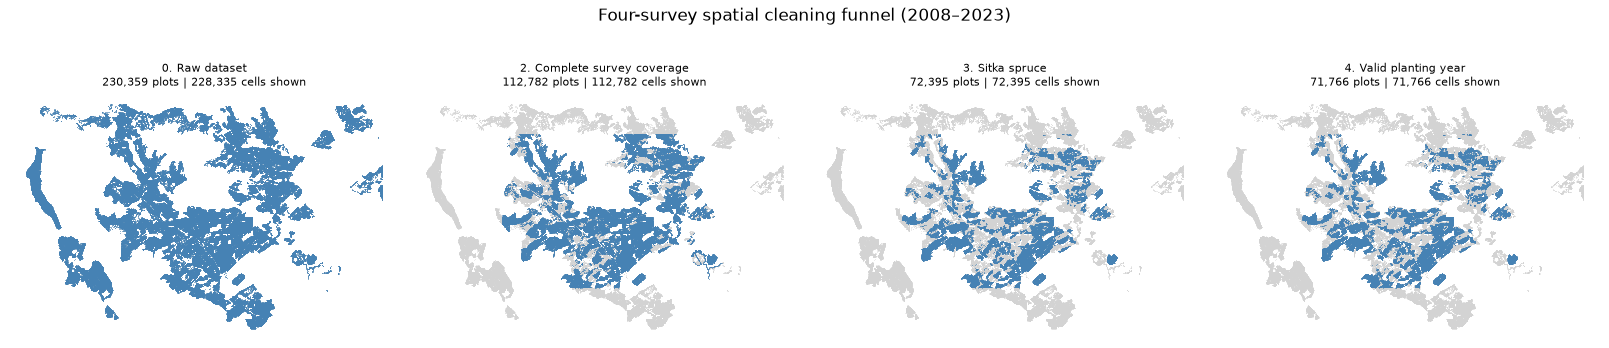

In [18]:
# Purpose: Map the main cumulative cleaning stages for the 4-year cohort.
# Key logic: This repeats the 6-year map logic so the two cohort footprints are easy to compare.

main_four_year_stages = [
    "0. Raw dataset",
    "2. Complete survey coverage",
    "3. Sitka spruce",
    "4. Valid planting year",
]

plot_cumulative_stage_map(
    four_year_stages,
    funnel4,
    main_four_year_stages,
    "Four-survey spatial cleaning funnel (2008–2023)",
    colour="steelblue",
)

**How to read these maps.** Each panel is cumulative: green/blue cells are the plots
still retained after the named stage, shown on top of the full 2023 grid footprint
in light grey. The important visual question is whether a filter removes plots
evenly across the forest or disproportionately removes particular areas.

The main spatial cuts are complete survey coverage, Sitka spruce, and valid
planting year. Plausible age and plausible height are still part of the cleaning
function, but they do not remove additional plots in the current funnel, so they
are not repeated as separate map panels.

---
## 3. Four-Year vs Six-Year Dataset Comparison


In [19]:
# Purpose: Compare descriptive statistics for the two cleaned cohorts.
# Key logic: describe calculates count, mean, standard deviation, quartiles, minimum, and maximum for each selected numeric column.

# Summary statistics comparison
compare_vars = ["Age", "Top_Height95", "Vol95", "Vol_RM95", "CanopyCover", "LAI", "yldc"]

summary_4 = d4[compare_vars].describe().round(2)
summary_6 = d6[compare_vars].describe().round(2)

print("=== Four-year cleaned dataset ===")
print(f"Rows: {len(d4):,}  |  Unique plots: {d4['identification'].nunique():,}")
print(f"Years: {sorted(d4['LiDAR_year'].unique())}")
display(summary_4)

print("\n=== Six-year cleaned dataset ===")
print(f"Rows: {len(d6):,}  |  Unique plots: {d6['identification'].nunique():,}")
print(f"Years: {sorted(d6['LiDAR_year'].unique())}")
display(summary_6)


=== Four-year cleaned dataset ===
Rows: 287,064  |  Unique plots: 71,766
Years: [np.int32(2008), np.int32(2012), np.int32(2021), np.int32(2023)]


,Age,Top_Height95,Vol95,Vol_RM95,CanopyCover,LAI,yldc
count,287064.00,287064.00,286676.00,287064.00,287064.00,287064.00,287064.00
mean,36.64,20.25,15.27,19.02,0.71,1.94,17.29
std,16.63,9.27,14.50,16.30,0.24,2.69,5.33
min,1.00,2.36,0.00,-0.19,0.00,0.00,2.00
25%,25.00,12.90,5.08,6.44,0.61,0.49,12.00
50%,35.00,19.46,11.68,15.66,0.78,0.87,18.00
75%,46.00,27.33,20.91,27.82,0.88,1.78,22.00
max,94.00,57.10,231.34,228.82,1.00,23.02,24.00



=== Six-year cleaned dataset ===
Rows: 83,382  |  Unique plots: 13,897
Years: [np.int32(2002), np.int32(2006), np.int32(2008), np.int32(2012), np.int32(2021), np.int32(2023)]


,Age,Top_Height95,Vol95,Vol_RM95,CanopyCover,LAI,yldc
count,83382.00,83382.00,83280.00,83382.00,83382.00,83382.00,83382.00
mean,31.64,21.68,12.40,20.39,0.75,1.61,21.47
std,12.37,7.97,8.63,14.01,0.21,2.08,3.61
min,2.00,2.37,0.00,-0.04,0.00,0.00,2.00
25%,22.00,15.42,6.43,10.20,0.66,0.55,20.00
50%,31.00,21.84,11.03,18.27,0.81,0.90,24.00
75%,38.00,27.73,16.52,28.03,0.90,1.57,24.00
max,90.00,48.86,121.86,152.17,1.00,18.05,24.00


**Table interpretation.** Compare the medians, ranges, and sample sizes rather than only the means. Similar summaries suggest that the smaller six-survey cohort retains a broadly comparable population; large differences would indicate selection bias caused by requiring the two earlier surveys.


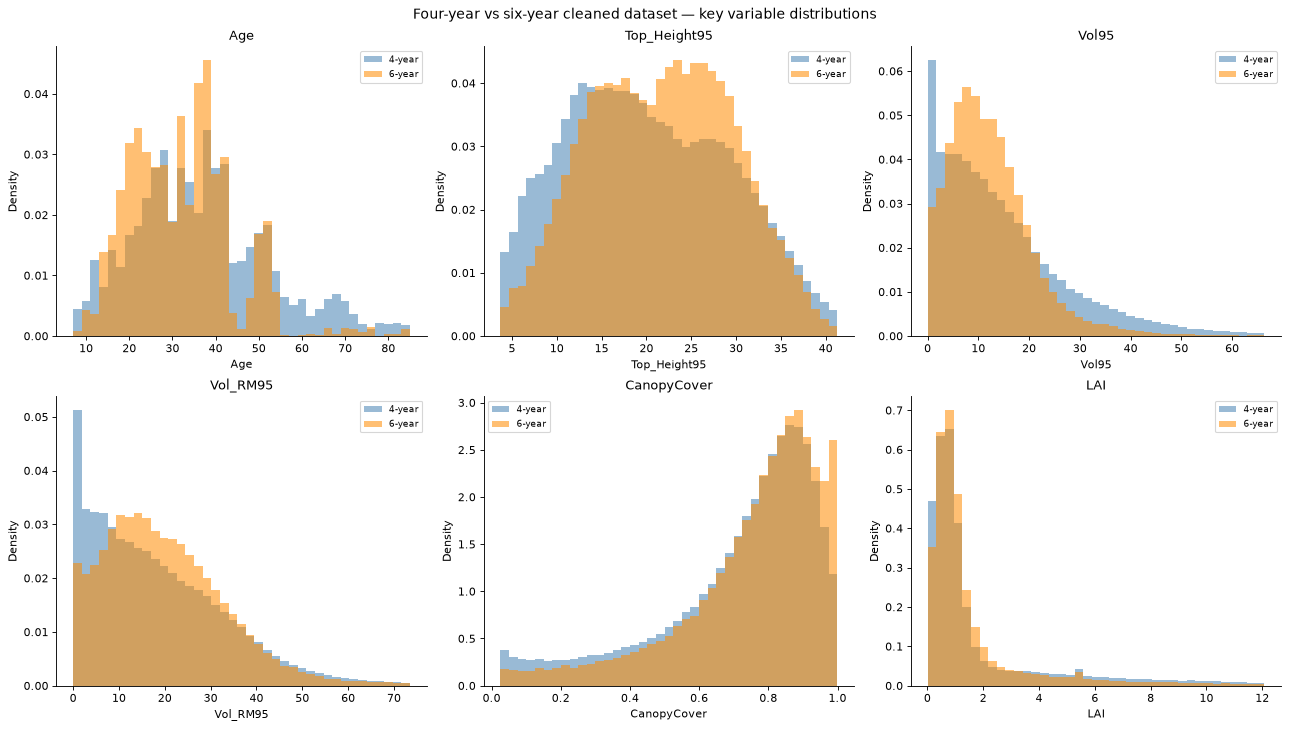

In [20]:
# Purpose: Compare the shapes of important variable distributions between cohorts.
# Key logic: The 1st and 99th percentiles set robust plotting limits; density=True allows differently sized cohorts to be compared on the same scale.

# Key variable distributions — 4yr vs 6yr overlaid
fig, axes = plt.subplots(2, 3, figsize=(16, 9), layout="constrained")

for ax, col in zip(axes.flat, compare_vars[:6]):
    v4 = d4[col].replace(0, np.nan).dropna()
    v6 = d6[col].replace(0, np.nan).dropna()
    lo = min(v4.quantile(0.01), v6.quantile(0.01))
    hi = max(v4.quantile(0.99), v6.quantile(0.99))
    bins = np.linspace(lo, hi, 40)
    ax.hist(v4, bins=bins, alpha=0.55, density=True, label="4-year", color="steelblue", edgecolor="none")
    ax.hist(v6, bins=bins, alpha=0.55, density=True, label="6-year", color="darkorange", edgecolor="none")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle("Four-year vs six-year cleaned dataset — key variable distributions", fontsize=13)
plt.show()


**Plot interpretation.** Each histogram is a density, so the shapes can be compared even though the cohorts contain different numbers of rows. Strong overlap means the cohorts have similar distributions. A shifted or narrower orange distribution means the six-survey requirement selects a different subset of stands.


### Summary — Cleaning Funnel and Cohort Comparison
- The largest row loss occurs at the Sitka spruce filter and the complete-trajectory requirement.
- The six-year cohort retains more unique plots than the four-year cohort but requires plots that existed in 2002/2006 — an older, spatially sparser subset.
- The four-year cohort covers 2008–2023 and is better aligned with the main survey expansion; it will have better spatial coverage and more even age distribution.
- Key variable distributions are broadly similar between cohorts, but the six-year dataset skews older (plots must have been surveyed in 2002/2006).
- For PINN/Chapman-Richards modelling, the four-year cohort is likely more suitable for training; the six-year cohort provides a longer time window for parameter estimation.


---
## 4. Remaining Issues in the Cleaned Dataset

Cleaning removes gross errors but does not resolve every data quality concern.
This section audits what survives the funnel.


In [21]:
# Purpose: Check whether the suspected LAI ceiling remains after cleaning.
# Key logic: Grouping by survey year reveals whether the issue is concentrated in one acquisition.

# LAI ceiling in cleaned four-year data
lai_cap_4 = np.isclose(d4["LAI"], 5.5, atol=0.01).sum()
print(f"LAI ≈ 5.5 rows remaining in 4-year cleaned data: {lai_cap_4:,} ({lai_cap_4/len(d4)*100:.1f}%)")
by_year = d4.groupby("LiDAR_year").apply(lambda g: np.isclose(g["LAI"], 5.5, atol=0.01).sum())
print(by_year.to_string())


LAI ≈ 5.5 rows remaining in 4-year cleaned data: 1,524 (0.5%)
LiDAR_year
2008       1
2012    1372
2021     151
2023       0


**Interpretation.** If the ceiling remains across several years, cleaning has not removed it and it cannot be attributed automatically to one survey.

In [22]:
# Purpose: Measure how often the height-percentile inversion remains after cleaning.
# Key logic: The mean signed gap is negative when Top_Height99 is lower than Top_Height95.

# Top_Height99 < Top_Height95 in cleaned data
flip = d4["Top_Height99"].lt(d4["Top_Height95"])
print(f"Top_Height99 < Top_Height95 : {flip.sum():,} rows ({flip.mean()*100:.1f}%)")
print(f"Mean gap when flipped: {(d4.loc[flip,'Top_Height99'] - d4.loc[flip,'Top_Height95']).mean():.3f} m")


Top_Height99 < Top_Height95 : 183,647 rows (64.0%)
Mean gap when flipped: -0.685 m


**Interpretation.** Persistence after cleaning shows that the inversion is not caused only by implausible records. Top_Height95 remains the safer primary height variable pending metadata clarification.

In [23]:
# Purpose: Verify that planting year stays fixed within repeated plots.
# Key logic: groupby plus nunique counts distinct planting years per identification rather than the number of records.

# Planting year consistency within a plot across surveys
plyr_var = (
    d4.groupby("identification")["plyr"]
    .nunique()
    .value_counts()
    .sort_index()
)
print("Number of distinct planting years per plot (cleaned 4-year data):")
print(plyr_var.to_string())
inconsistent = (d4.groupby("identification")["plyr"].nunique() > 1).sum()
print(f"\nPlots with inconsistent planting year: {inconsistent:,}")


Number of distinct planting years per plot (cleaned 4-year data):
plyr
1    71766

Plots with inconsistent planting year: 0


**Interpretation.** More than one planting year per plot would invalidate a smooth age trajectory. A zero inconsistent-plot count supports treating plyr as fixed.

In [24]:
# Purpose: Calculate change in height between consecutive records and flag large decreases.
# Key logic: Sorting is essential before groupby.diff; diff subtracts the previous survey value within each plot.

# Height drops between consecutive surveys — flag possible disturbance / harvesting
d4_sorted = d4.sort_values(["identification", "LiDAR_year"])
d4_sorted = d4_sorted.copy()
d4_sorted["height_change"] = d4_sorted.groupby("identification")["Top_Height95"].diff()

# Flag a drop of more than 2 m between consecutive surveys
DROP_THRESHOLD = 2.0
d4_sorted["height_drop_flag"] = d4_sorted["height_change"].lt(-DROP_THRESHOLD)

drop_plots = d4_sorted.groupby("identification")["height_drop_flag"].any()
n_drop = drop_plots.sum()
print(f"Plots with height drop > {DROP_THRESHOLD} m between surveys: {n_drop:,} ({n_drop/drop_plots.__len__()*100:.1f}%)")
print()
print("Height change distribution between consecutive surveys:")
print(d4_sorted["height_change"].dropna().describe().round(3))


Plots with height drop > 2.0 m between surveys: 3,025 (4.2%)

Height change distribution between consecutive surveys:
count    215298.000
mean          2.901
std           2.778
min         -47.034
25%           1.566
50%           2.535
75%           4.051
max          28.472
Name: height_change, dtype: float64


**Interpretation.** Flagged decreases may represent disturbance, harvesting, edge effects, or survey-processing differences. The flag separates these trajectories without assuming a cause.

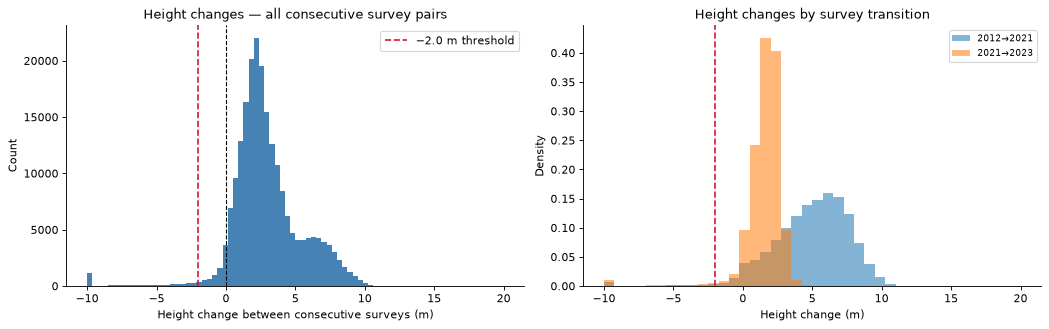

In [25]:
# Purpose: Visualise height changes overall and separately for each survey transition.
# Key logic: clip changes plotting limits only; it does not alter the stored observations.

# Show distribution of height changes to understand typical vs anomalous values
fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")

changes = d4_sorted["height_change"].dropna()
axes[0].hist(changes.clip(-10, 20), bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].axvline(-DROP_THRESHOLD, color="crimson", linewidth=1.5, linestyle="--", label=f"−{DROP_THRESHOLD} m threshold")
axes[0].set_xlabel("Height change between consecutive surveys (m)")
axes[0].set_ylabel("Count")
axes[0].set_title("Height changes — all consecutive survey pairs")
axes[0].legend()

# By survey-year transition
transitions = d4_sorted.dropna(subset=["height_change"]).copy()
transitions["transition"] = (
    transitions.groupby("identification")["LiDAR_year"]
    .shift(1)
    .astype("Int64")
    .astype(str)
    .str.replace("<NA>","",regex=False)
    + "→"
    + transitions["LiDAR_year"].astype(str)
)
transitions = transitions[transitions["transition"].str.contains(r"→\d")]
for trans, grp in transitions.groupby("transition"):
    axes[1].hist(grp["height_change"].clip(-10, 20), bins=40, alpha=0.55, density=True, label=trans)
axes[1].axvline(-DROP_THRESHOLD, color="crimson", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Height change (m)")
axes[1].set_ylabel("Density")
axes[1].set_title("Height changes by survey transition")
axes[1].legend(fontsize=8)

plt.show()


**Plot interpretation.** Values below zero mean measured top height decreased between surveys. The red line marks the chosen disturbance flag of a decrease greater than 2 m. Differences between transitions may reflect unequal time gaps, forest disturbance, or changes in LiDAR acquisition and processing; the plot alone cannot identify the cause.


In [26]:
# Purpose: Verify that assigned yield class remains fixed within plots.
# Key logic: Rows with yldc=0 are excluded because zero represents unknown rather than a genuine class.

# Yield class consistency in cleaned data
yldc_var = (
    d4[d4["yldc"].gt(0)]
    .groupby("identification")["yldc"]
    .nunique()
    .value_counts()
    .sort_index()
)
print("Distinct yield classes per plot in 4-year cleaned data (yldc > 0):")
print(yldc_var.to_string())


Distinct yield classes per plot in 4-year cleaned data (yldc > 0):
yldc
1    71766


**Interpretation.** One distinct non-zero yldc per plot confirms that assigned yield class is fixed through time in the cleaned cohort.

#### Derived species-specific yield class (`GYCspec95`)

Unlike assigned `yldc`, `GYCspec95` is a continuous derived value associated with
the 95th-percentile height calculation. This check describes its validity, range,
variation through time, and relationship with the fixed assigned yield class. The supplied field documentation confirms that it is derived from the Chapman-Richards site-index equation using `Top_Height95`, `Age`, and `p1–p5`.

GYCspec95 quality summary


,GYCspec95 rows
rows,287064
missing,5168
infinite,0
zero_or_negative,4463
finite_positive,277433
greater_than_40,7533


Finite GYCspec95 distribution


,GYCspec95
count,281896.000
mean,23.976
std,135.452
min,-9.764
1%,-1.084
5%,3.665
25%,14.088
50%,20.575
75%,25.747
95%,34.392


Plots with more than one finite positive GYCspec95 value: 69,768 / 71,766 (97.2%)
GYCspec95 vs yldc        : rho=0.471, p=0.000e+00, n=277,433
GYCspec95 vs Age         : rho=-0.273, p=0.000e+00, n=277,433


GYCspec95 vs Top_Height95: rho=0.360, p=0.000e+00, n=277,433


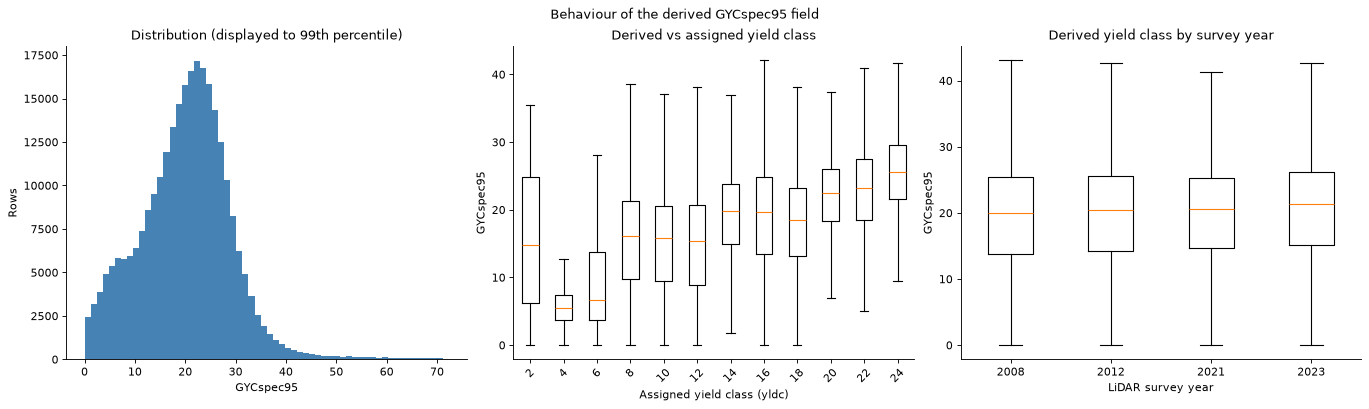

In [27]:
# Purpose: Examine the distribution and temporal behaviour of GYCspec95.
# Key logic: Invalid values are counted before filtering; plots use finite positive
# values and robust percentile limits so a few extreme results do not hide the bulk.

gyc95 = d4["GYCspec95"]
finite_gyc95 = np.isfinite(gyc95)
positive_finite_gyc95 = finite_gyc95 & gyc95.gt(0)

gyc95_quality = pd.Series({
    "rows": len(d4),
    "missing": int(gyc95.isna().sum()),
    "infinite": int(np.isinf(gyc95).sum()),
    "zero_or_negative": int((finite_gyc95 & gyc95.le(0)).sum()),
    "finite_positive": int(positive_finite_gyc95.sum()),
    "greater_than_40": int((finite_gyc95 & gyc95.gt(40)).sum()),
}, name="GYCspec95 rows")

print("GYCspec95 quality summary")
display(gyc95_quality.to_frame())

print("Finite GYCspec95 distribution")
display(
    gyc95[finite_gyc95]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame("GYCspec95")
    .round(3)
)

# Replace invalid values with NaN for analysis without changing d4 itself.
d4_gyc95 = d4.copy()
d4_gyc95["GYCspec95_valid"] = d4_gyc95["GYCspec95"].where(
    positive_finite_gyc95
)

# Assigned yldc should be fixed; derived GYCspec95 is expected to vary by survey.
gyc95_unique_by_plot = (
    d4_gyc95.groupby("identification")["GYCspec95_valid"].nunique()
)
changing_gyc95_plots = int(gyc95_unique_by_plot.gt(1).sum())

print(
    "Plots with more than one finite positive GYCspec95 value: "
    f"{changing_gyc95_plots:,} / {len(gyc95_unique_by_plot):,} "
    f"({changing_gyc95_plots / len(gyc95_unique_by_plot) * 100:.1f}%)"
)

# Calculate descriptive rank correlations using valid rows only.
correlation_data = d4_gyc95[
    ["GYCspec95_valid", "yldc", "Age", "Top_Height95"]
].dropna()
correlation_data = correlation_data[correlation_data["yldc"].gt(0)]

for comparison in ["yldc", "Age", "Top_Height95"]:
    rho, p_value = spearmanr(
        correlation_data["GYCspec95_valid"],
        correlation_data[comparison],
    )
    print(
        f"GYCspec95 vs {comparison:<12}: "
        f"rho={rho:.3f}, p={p_value:.3e}, n={len(correlation_data):,}"
    )

# Use the 99th percentile only as a display limit; no rows are deleted from d4.
plot_limit = d4_gyc95["GYCspec95_valid"].quantile(0.99)
plot_data = d4_gyc95[
    d4_gyc95["GYCspec95_valid"].le(plot_limit)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5), layout="constrained")

# Panel 1: overall shape of the valid distribution.
axes[0].hist(
    plot_data["GYCspec95_valid"],
    bins=60,
    color="steelblue",
    edgecolor="none",
)
axes[0].set_xlabel("GYCspec95")
axes[0].set_ylabel("Rows")
axes[0].set_title("Distribution (displayed to 99th percentile)")

# Panel 2: compare the derived value with fixed assigned yield classes.
assigned_classes = sorted(plot_data.loc[plot_data["yldc"].gt(0), "yldc"].unique())
assigned_groups = [
    plot_data.loc[plot_data["yldc"].eq(value), "GYCspec95_valid"].dropna()
    for value in assigned_classes
]
axes[1].boxplot(
    assigned_groups,
    tick_labels=[str(value) for value in assigned_classes],
    showfliers=False,
)
axes[1].set_xlabel("Assigned yield class (yldc)")
axes[1].set_ylabel("GYCspec95")
axes[1].set_title("Derived vs assigned yield class")
axes[1].tick_params(axis="x", rotation=45)

# Panel 3: check whether the derived distribution changes by survey year.
survey_years = sorted(plot_data["LiDAR_year"].unique())
year_groups = [
    plot_data.loc[
        plot_data["LiDAR_year"].eq(year), "GYCspec95_valid"
    ].dropna()
    for year in survey_years
]
axes[2].boxplot(
    year_groups,
    tick_labels=[str(year) for year in survey_years],
    showfliers=False,
)
axes[2].set_xlabel("LiDAR survey year")
axes[2].set_ylabel("GYCspec95")
axes[2].set_title("Derived yield class by survey year")

fig.suptitle("Behaviour of the derived GYCspec95 field")
plt.show()

**Interpretation.** `GYCspec95` should not be treated as a second fixed yield-class
label. It varies within most repeated plots and has missing, non-positive, and very
large values. The plotted 99th-percentile limit improves readability but is not a
cleaning rule. Association with assigned `yldc` shows whether the fields broadly
rank stands similarly; association with age and `Top_Height95` indicates how much
the derived value may recycle information already present in the intended model.

Because its exact formula is now confirmed, the modelling reason for exclusion is clearer: `GYCspec95` is derived directly from `Top_Height95` and `Age`. Keep `yldc` as the fixed management label and exclude `GYCspec95` from top-height predictors and routine exports to avoid target leakage and unstable values.

#### Spatial distribution of remaining flagged concerns

These maps do not apply additional cleaning. They show where retained plots have
possible disturbance, LAI ceiling behaviour, negative generic-equation volume, or
non-standard cell area. Spatial clustering matters because excluding one of these
issues later could disproportionately remove a part of the forest.

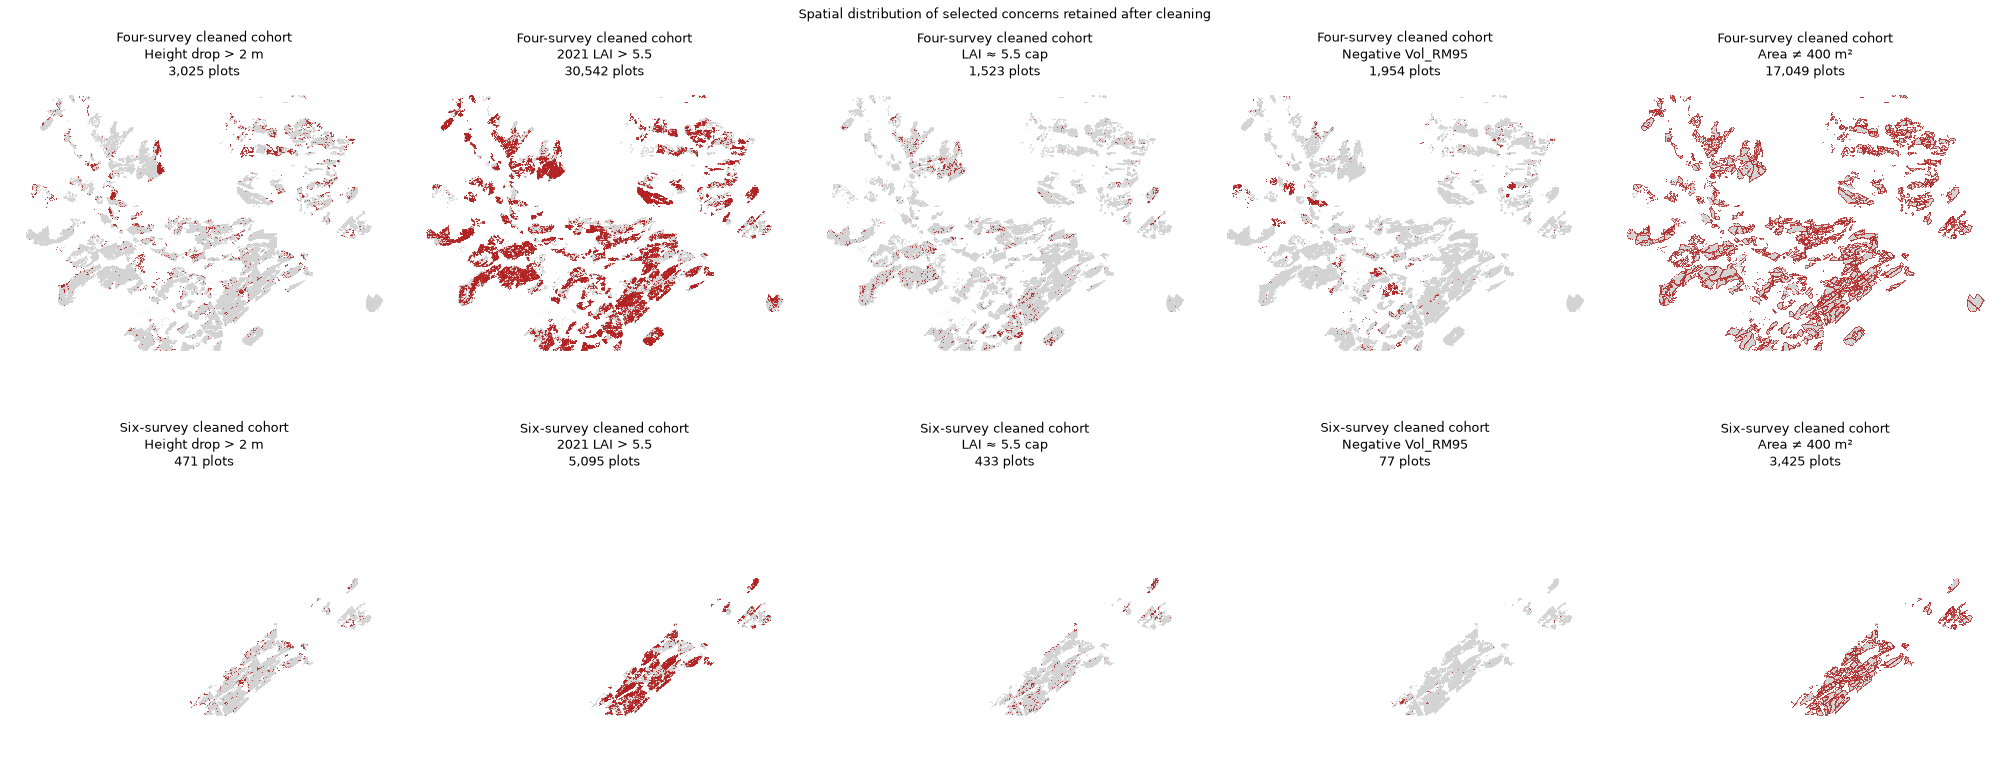

In [28]:
# Purpose: Map selected concerns that remain inside both cleaned cohorts.
# Key logic: Each issue is reduced to plot IDs using "any year" logic, then shown
# as red representative points over the grey cleaned-cohort footprint.

def add_structural_change_flags(data):
    """Calculate consecutive-survey changes without deleting any observations."""
    flagged = data.sort_values(["identification", "LiDAR_year"]).copy()
    grouped = flagged.groupby("identification")

    flagged["height_change"] = grouped["Top_Height95"].diff()
    flagged["canopy_change"] = grouped["CanopyCover"].diff()
    flagged["lai_change"] = grouped["LAI"].diff()

    flagged["possible_disturbance"] = flagged["height_change"].lt(-2.0)
    flagged["canopy_drop"] = flagged["canopy_change"].lt(-0.15)
    flagged["lai_drop"] = flagged["lai_change"].lt(-1.0)

    # A combined flag requires a height drop plus a canopy or LAI decline.
    flagged["combined_structural_disturbance"] = (
        flagged["possible_disturbance"]
        & (flagged["canopy_drop"] | flagged["lai_drop"])
    )
    return flagged


d4_flagged = add_structural_change_flags(d4)
d6_flagged = add_structural_change_flags(d6)


def plot_level_issue_ids(data):
    """Return plot identifiers affected by each issue in at least one survey."""
    disturbed_ids = (
        data.groupby("identification")["possible_disturbance"]
        .any()
        .loc[lambda values: values]
        .index
    )
    lai_high_ids = data.loc[
        data["LiDAR_year"].eq(2021) & data["LAI"].gt(5.5),
        "identification",
    ].unique()
    lai_cap_ids = data.loc[
        np.isclose(data["LAI"], 5.5, atol=0.01),
        "identification",
    ].unique()
    negative_volume_ids = data.loc[
        data["Vol_RM95"].lt(0),
        "identification",
    ].unique()
    irregular_area_ids = data.loc[
        ~np.isclose(data["area"], 400),
        "identification",
    ].unique()

    return {
        "Height drop > 2 m": disturbed_ids,
        "2021 LAI > 5.5": lai_high_ids,
        "LAI ≈ 5.5 cap": lai_cap_ids,
        "Negative Vol_RM95": negative_volume_ids,
        "Area ≠ 400 m²": irregular_area_ids,
    }


cohort_issue_maps = {
    "Four-survey cleaned cohort": {
        "map": map_2023.loc[map_2023["identification"].isin(d4["identification"])],
        "issues": plot_level_issue_ids(d4_flagged),
    },
    "Six-survey cleaned cohort": {
        "map": map_2023.loc[map_2023["identification"].isin(d6["identification"])],
        "issues": plot_level_issue_ids(d6_flagged),
    },
}

issue_titles = list(next(iter(cohort_issue_maps.values()))["issues"])
fig, axes = plt.subplots(
    2,
    len(issue_titles),
    figsize=(5 * len(issue_titles), 10),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for row, (cohort_name, details) in enumerate(cohort_issue_maps.items()):
    cohort_map = details["map"]

    for col, issue_name in enumerate(issue_titles):
        axis = axes[row, col]
        affected_ids = details["issues"][issue_name]
        affected = cohort_map[
            cohort_map["identification"].isin(affected_ids)
        ]

        axis.scatter(
            cohort_map["map_x"], cohort_map["map_y"],
            s=0.4, color="lightgrey", linewidths=0, rasterized=True,
        )
        axis.scatter(
            affected["map_x"], affected["map_y"],
            s=0.5, color="firebrick", linewidths=0, rasterized=True,
        )
        axis.set_title(
            f"{cohort_name}\n{issue_name}\n{len(affected):,} plots"
        )
        axis.set_axis_off()
        axis.set_aspect("equal")

fig.suptitle("Spatial distribution of selected concerns retained after cleaning")
plt.show()

**Interpretation.** Red points indicate plots that remain usable for the main
height analysis but require care for a particular secondary variable. Negative
`Vol_RM95` should trigger a local volume filter, not removal from the age–height
dataset. Irregular area often follows survey boundaries and is not automatically
an error. Clusters of height drops or LAI behaviour may indicate disturbance,
management, acquisition differences, or spatially structured measurement issues.

,cohort,plots,assigned thinned plots,recent thinning plots,combined disturbance plots,recent thinning + disturbance
0,four_year,71766,23254,16840,1676,255
1,six_year,13897,11592,10934,284,251


,transition,plots,thinning_between_surveys,combined_disturbance,overlap
0,2002→2006,13897,537,47,1
1,2006→2008,13897,924,16,0
2,2008→2012,13897,1454,53,10
3,2012→2021,13897,4046,70,9
4,2021→2023,13897,3641,100,2


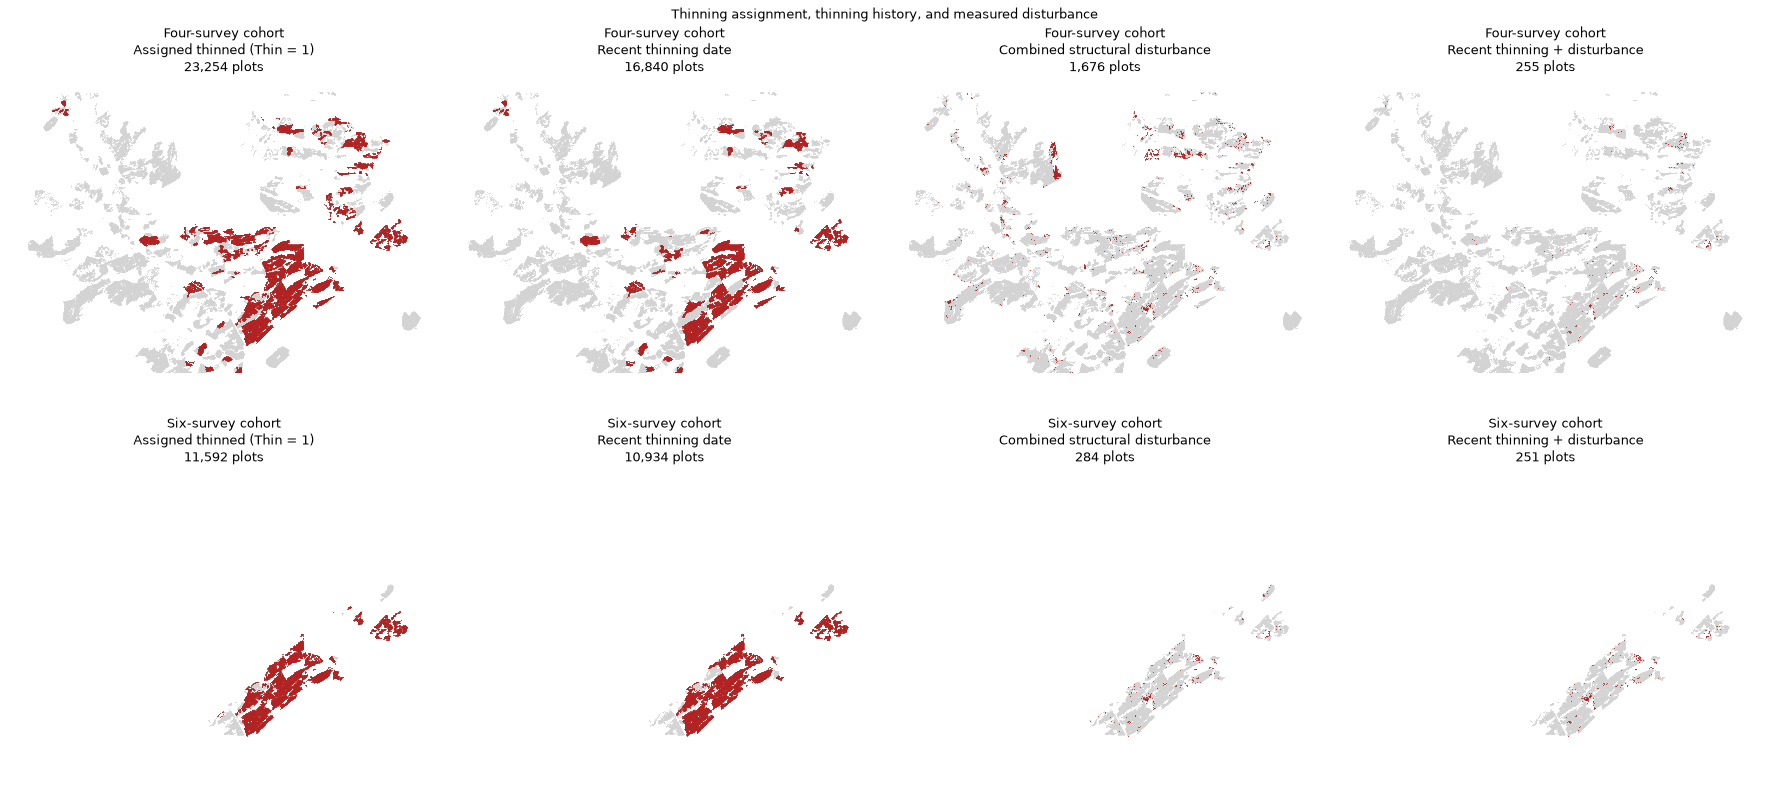

In [29]:
# Purpose: Compare thinning metadata with measured structural disturbance.
# Key logic: Plot-level any() summaries avoid counting the same plot once per year;
# transition summaries test whether thinning dates fall between survey pairs.

def build_disturbance_summary(flagged_data, cohort_start):
    """Create one thinning/disturbance record per plot."""
    data = flagged_data.copy()
    data["assigned_thinned"] = data["Thin"].eq(1.0)
    data["recent_thinning"] = (
        data["last_thinn"].ge(cohort_start)
        & data["last_thinn"].le(data["LiDAR_year"].max())
    )

    summary = (
        data.groupby("identification")
        .agg(
            any_assigned_thinned=("assigned_thinned", "any"),
            any_recent_thinning=("recent_thinning", "any"),
            any_combined_structural_disturbance=(
                "combined_structural_disturbance", "any"
            ),
        )
        .reset_index()
    )
    summary["recent_thinning_and_combined"] = (
        summary["any_recent_thinning"]
        & summary["any_combined_structural_disturbance"]
    )
    return summary


four_year_disturbance_summary = build_disturbance_summary(d4_flagged, 2008)
six_year_disturbance_summary = build_disturbance_summary(d6_flagged, 2002)

disturbance_alignment_summary = pd.DataFrame([
    {
        "cohort": "four_year",
        "plots": len(four_year_disturbance_summary),
        "assigned thinned plots": int(
            four_year_disturbance_summary["any_assigned_thinned"].sum()
        ),
        "recent thinning plots": int(
            four_year_disturbance_summary["any_recent_thinning"].sum()
        ),
        "combined disturbance plots": int(
            four_year_disturbance_summary[
                "any_combined_structural_disturbance"
            ].sum()
        ),
        "recent thinning + disturbance": int(
            four_year_disturbance_summary[
                "recent_thinning_and_combined"
            ].sum()
        ),
    },
    {
        "cohort": "six_year",
        "plots": len(six_year_disturbance_summary),
        "assigned thinned plots": int(
            six_year_disturbance_summary["any_assigned_thinned"].sum()
        ),
        "recent thinning plots": int(
            six_year_disturbance_summary["any_recent_thinning"].sum()
        ),
        "combined disturbance plots": int(
            six_year_disturbance_summary[
                "any_combined_structural_disturbance"
            ].sum()
        ),
        "recent thinning + disturbance": int(
            six_year_disturbance_summary[
                "recent_thinning_and_combined"
            ].sum()
        ),
    },
])
display(disturbance_alignment_summary)


def transition_alignment(flagged_data):
    """Summarise thinning dates and disturbance for each survey interval."""
    data = flagged_data.sort_values(["identification", "LiDAR_year"]).copy()
    data["previous_year"] = data.groupby("identification")["LiDAR_year"].shift()
    data["thinning_between_surveys"] = (
        data["last_thinn"].gt(data["previous_year"])
        & data["last_thinn"].le(data["LiDAR_year"])
    )
    data["transition"] = (
        data["previous_year"].astype("Int64").astype(str)
        + "→"
        + data["LiDAR_year"].astype(str)
    )
    valid = data[data["previous_year"].notna()].copy()
    valid["aligned"] = (
        valid["thinning_between_surveys"]
        & valid["combined_structural_disturbance"]
    )
    return (
        valid.groupby("transition")
        .agg(
            plots=("identification", "nunique"),
            thinning_between_surveys=("thinning_between_surveys", "sum"),
            combined_disturbance=("combined_structural_disturbance", "sum"),
            overlap=("aligned", "sum"),
        )
        .reset_index()
    )


six_year_alignment_summary = transition_alignment(d6_flagged)
display(six_year_alignment_summary)


cohort_disturbance_maps = {
    "Four-survey cohort": {
        "map": map_2023.loc[
            map_2023["identification"].isin(
                four_year_disturbance_summary["identification"]
            )
        ],
        "summary": four_year_disturbance_summary,
    },
    "Six-survey cohort": {
        "map": map_2023.loc[
            map_2023["identification"].isin(
                six_year_disturbance_summary["identification"]
            )
        ],
        "summary": six_year_disturbance_summary,
    },
}

map_layers = {
    "Assigned thinned (Thin = 1)": "any_assigned_thinned",
    "Recent thinning date": "any_recent_thinning",
    "Combined structural disturbance": "any_combined_structural_disturbance",
    "Recent thinning + disturbance": "recent_thinning_and_combined",
}

fig, axes = plt.subplots(
    2,
    len(map_layers),
    figsize=(5.5 * len(map_layers), 10),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for row, (cohort_name, details) in enumerate(cohort_disturbance_maps.items()):
    cohort_map = details["map"].merge(
        details["summary"], on="identification", how="left"
    )

    for col, (title, flag_column) in enumerate(map_layers.items()):
        axis = axes[row, col]
        affected = cohort_map[cohort_map[flag_column].fillna(False)]

        axis.scatter(
            cohort_map["map_x"], cohort_map["map_y"],
            s=0.4, color="lightgrey", linewidths=0, rasterized=True,
        )
        axis.scatter(
            affected["map_x"], affected["map_y"],
            s=0.5, color="firebrick", linewidths=0, rasterized=True,
        )
        axis.set_title(f"{cohort_name}\n{title}\n{len(affected):,} plots")
        axis.set_axis_off()
        axis.set_aspect("equal")

fig.suptitle("Thinning assignment, thinning history, and measured disturbance")
plt.show()

**Interpretation.** The assigned-thinning map is especially important for volume:
`Thin` determines which coefficient pair is used to derive volume, so geographic
separation of thinning regimes can also create geographic differences in derived
volume. The overlap columns show how often a recorded thinning date coincides with
the conservative structural-disturbance proxy. Low overlap does not invalidate the
metadata: canopy recovery, inaccurate dates, unequal survey intervals, and other
disturbances can all weaken alignment.

### Summary — Remaining Issues After Cleaning

- **LAI ceiling:** retained and flagged; do not treat values near 5.5 as
  unconstrained continuous measurements.
- **Top_Height99 inversion:** retained but excluded from the planned model exports;
  `Top_Height95` remains the primary height target.
- **Planting year:** constant within every repeated cleaned plot.
- **Assigned yield class:** constant within every repeated cleaned plot; class 0
  remains an unknown category.
- **Height and combined structural drops:** retained as possible disturbance rather
  than automatically deleted. Use sensitivity analyses and thinning metadata.
- **Negative Vol_RM95:** retained in the height dataset and filtered locally only
  when volume is analysed; the documented equation can produce negative values at low heights.
- **Cell area:** irregular cells are mapped and retained because boundary cells may
  legitimately differ from 400 m².

---
## 5. Volume Equation Investigation

Three candidate equations for Sitka spruce, using `Top_Height95` as the height variable.

| Equation | Formula |
|---|---|
| Thinned SS   | `Vol = 3.509144 × TH^1.478136` |
| Unthinned SS | `Vol = 2.922183 × TH^1.694732` |
| Alternative  | `Vol = −35.8733 + 5.3486 × TH^1.5424` |


In [30]:
# Purpose: Reconstruct three candidate volume equations from top height.
# Key logic: Exponentiation uses **; the alternative equation is also clipped at zero because it can produce negative predictions for short stands.

# Implement equations — use four-year cleaned SS dataset
TH = d4["Top_Height95"].values

vol_thinned   = 3.509144  * TH**1.478136
vol_unthinned = 2.922183  * TH**1.694732
vol_alt       = -35.8733  + 5.3486 * TH**1.5424

d4 = d4.copy()
d4["vol_eq_thinned"]   = vol_thinned
d4["vol_eq_unthinned"] = vol_unthinned
d4["vol_eq_alt"]       = vol_alt

# Clip alt equation at 0 (negative for very young stands)
d4["vol_eq_alt_clipped"] = d4["vol_eq_alt"].clip(lower=0)

print("Volume equation predicted ranges:")
for name, col in [("Thinned","vol_eq_thinned"),("Unthinned","vol_eq_unthinned"),("Alt","vol_eq_alt")]:
    print(f"  {name}: min={d4[col].min():.2f}  median={d4[col].median():.2f}  max={d4[col].max():.2f}")


Volume equation predicted ranges:
  Thinned: min=12.47  median=282.31  max=1386.03
  Unthinned: min=12.51  median=447.16  max=2771.81
  Alt: min=-15.78  median=484.86  max=2703.82


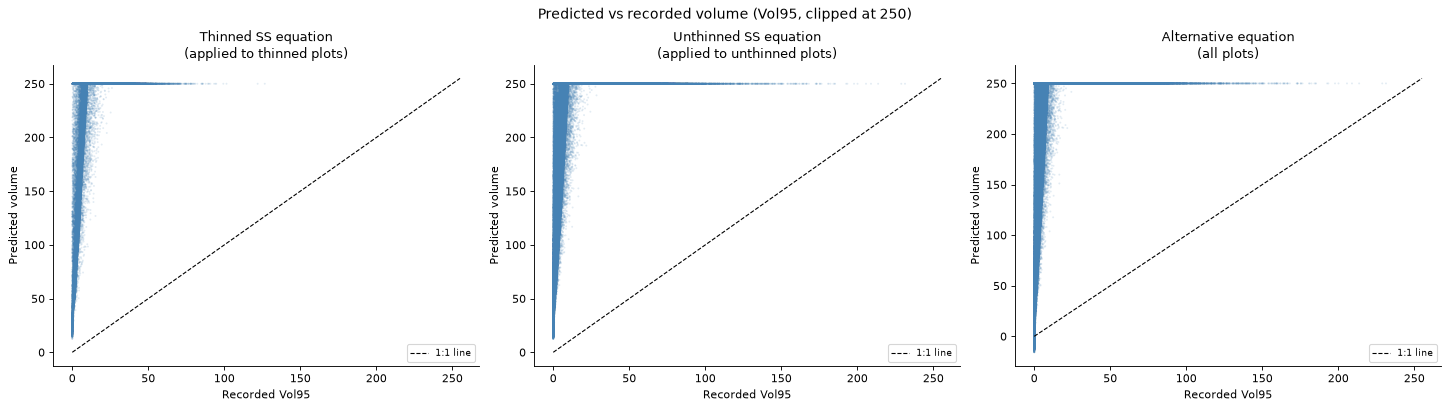

In [31]:
# Purpose: Compare reconstructed and recorded volume against a perfect-agreement line.
# Key logic: dropna is applied to both recorded and predicted columns; rasterized points reduce the size of vector figure exports.

# Predicted vs recorded Vol95 — one panel per equation
# Split by Thin status for thinned/unthinned equations
thinned_rows = d4[d4["Thin"].eq(1.0)].dropna(subset=["Vol95"])
unthinned_rows = d4[d4["Thin"].eq(0.0)].dropna(subset=["Vol95"])

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    layout="constrained",
)

clip_hi = 250

data_panels = [
    (
        thinned_rows,
        "vol_eq_thinned",
        "Thinned SS equation\n(applied to thinned plots)",
    ),
    (
        unthinned_rows,
        "vol_eq_unthinned",
        "Unthinned SS equation\n(applied to unthinned plots)",
    ),
    (
        d4.dropna(subset=["Vol95"]),
        "vol_eq_alt",
        "Alternative equation\n(all plots)",
    ),
]

for ax, (dat, eq_col, title) in zip(axes, data_panels):
    valid = dat.dropna(subset=["Vol95", eq_col])

    recorded = valid["Vol95"].clip(upper=clip_hi)
    predicted = valid[eq_col].clip(upper=clip_hi)

    ax.scatter(
        recorded,
        predicted,
        s=3,
        alpha=0.15,
        color="steelblue",
        edgecolor="none",
        rasterized=True,
    )

    lim = max(recorded.max(), predicted.max()) * 1.02
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="1:1 line")

    ax.set_xlabel("Recorded Vol95")
    ax.set_ylabel("Predicted volume")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle(
    "Predicted vs recorded volume (Vol95, clipped at 250)",
    fontsize=13,
)

plt.show()


**Plot interpretation.** The dashed 1:1 line represents perfect agreement between recorded and reconstructed volume. Points above it are over-predictions and points below it are under-predictions. These comparisons do not provide an independent validation if `Vol95` was originally calculated from the same height and equation coefficients.


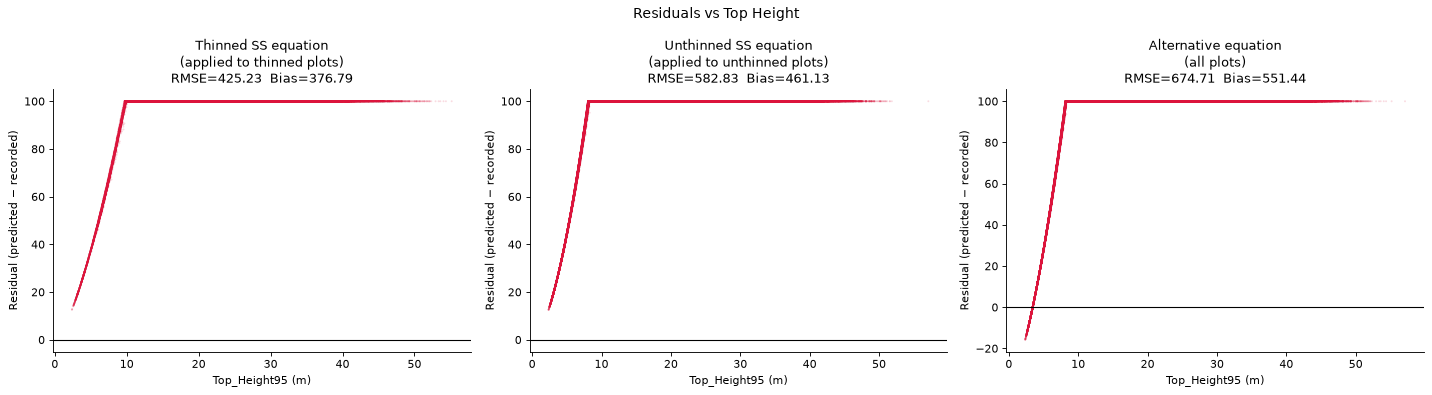

In [32]:
# Purpose: Show prediction errors from each candidate volume equation.
# Key logic: Residual equals predicted minus recorded, so positive values indicate over-prediction.

# Residual plots — predicted minus recorded
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (dat, eq_col, title) in zip(axes, data_panels):
    recorded  = dat["Vol95"].dropna()
    predicted = dat.loc[recorded.index, eq_col]
    residual  = predicted - recorded
    ax.scatter(dat.loc[recorded.index, "Top_Height95"],
               residual.clip(-100, 100),
               s=3, alpha=0.15, color="crimson", edgecolor="none")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("Top_Height95 (m)")
    ax.set_ylabel("Residual (predicted − recorded)")
    ax.set_title(title)
    rmse = np.sqrt((residual**2).mean())
    bias = residual.mean()
    ax.set_title(f"{title}\nRMSE={rmse:.2f}  Bias={bias:.2f}")

plt.suptitle("Residuals vs Top Height", fontsize=13)
plt.tight_layout()
plt.show()


**Interpretation.** Residuals centred near zero indicate little average bias. Curvature or widening spread indicates that equation error changes systematically with height or predicted volume.

In [33]:
# Purpose: Calculate comparable error metrics for the candidate equations.
# Key logic: RMSE penalises large errors more strongly than MAE; bias is the mean signed error; Spearman measures rank association.

# Summary statistics for each equation
stats_rows = []
for dat, eq_col, label in data_panels:
    rec = dat["Vol95"].dropna()
    pred = dat.loc[rec.index, eq_col]
    resid = pred - rec
    stats_rows.append({
        "equation": label.split("\n")[0].strip(),
        "n": len(rec),
        "RMSE": round(np.sqrt((resid**2).mean()), 2),
        "MAE": round(resid.abs().mean(), 2),
        "bias": round(resid.mean(), 2),
        "R2_spearman": round(spearmanr(rec, pred).statistic, 3),
    })
pd.DataFrame(stats_rows)


,equation,n,RMSE,MAE,bias,R2_spearman
0,Thinned SS equation,92908,425.23,376.79,376.79,0.872
1,Unthinned SS equation,193768,582.83,461.13,461.13,0.945
2,Alternative equation,286676,674.71,551.52,551.44,0.884


**Interpretation.** Lower RMSE and MAE indicate closer numerical agreement, while bias shows direction. These are reconstruction checks, not independent validation, because recorded volume appears derived from the same equations.

In [34]:
# Purpose: Check whether stored volume coefficients align with thinning status.
# Key logic: Grouping by g1, g3, and Thin reveals whether coefficients are lookup values rather than independent plot measurements.

# Does the choice between thinned/unthinned equation depend on the Thin column?
# Check how g1/g3 (per-plot coefficients) align with Thin status.
g_thin = d4.dropna(subset=["g1","g3"]).groupby(["g1","g3","Thin"]).size().reset_index(name="rows")
print("g1 / g3 / Thin alignment (confirms equations are pre-assigned per plot):")
display(g_thin.sort_values("rows", ascending=False).head(12))


g1 / g3 / Thin alignment (confirms equations are pre-assigned per plot):


,g1,g3,Thin,rows
8,2.922183,1.694732,0.0,127144
9,3.509144,1.478136,1.0,67896
2,1.279552,1.964780,0.0,56736
3,1.648721,1.715591,1.0,19724
0,0.123183,2.453028,0.0,4832
4,2.023301,1.669650,1.0,3572
6,2.066719,1.831874,0.0,3488
1,0.123183,2.453028,1.0,1320
7,2.101370,1.716840,0.0,1264
10,4.686913,1.225744,0.0,304


**Interpretation.** Repeated coefficient pairs aligned with Thin support the conclusion that g1 and g3 are assigned equation parameters and should not be treated as independent predictors.

### Summary — Volume Equations
- All three equations track the general trend but diverge at high heights (>30 m) where data are sparse.
- The thinned and unthinned equations have similar RMSE when applied to their respective subsets; bias varies.
- The alternative equation predicts negative volumes for very young/short stands and needs clipping.
- `g1` and `g3` in the dataset are exactly the thinned/unthinned equation coefficients pre-assigned per plot — confirming that `Vol95` was computed this way already. Using the equations to reconstruct Vol effectively reproduces `Vol95` by design.
- This means `Vol95`, `g1`, and `g3` are **not independent of each other**. For modelling, choose one: either use `Vol95` directly or use `Top_Height95` and predict volume externally.


---
## 6. Yield Class Investigation


In [35]:
# Purpose: Count plots whose assigned yield class changes across six surveys.
# Key logic: The min and max columns make any detected change easier to inspect.

# Does yield class vary within a plot across surveys?
d6_nonzero_yldc = d6[d6["yldc"].gt(0)].copy()
yldc_var = (
    d6_nonzero_yldc.groupby("identification")["yldc"]
    .agg(["nunique", "min", "max"])
)
changing = yldc_var[yldc_var["nunique"].gt(1)]
print(f"Plots with changing yldc across surveys: {len(changing):,} / {len(yldc_var):,} ({len(changing)/len(yldc_var)*100:.1f}%)")
print(yldc_var["nunique"].value_counts().sort_index().to_string())


Plots with changing yldc across surveys: 0 / 13,897 (0.0%)
nunique
1    13897


**Interpretation.** A zero changing-plot count means yldc is a repeated fixed label in this dataset, not a new estimate made at every survey.

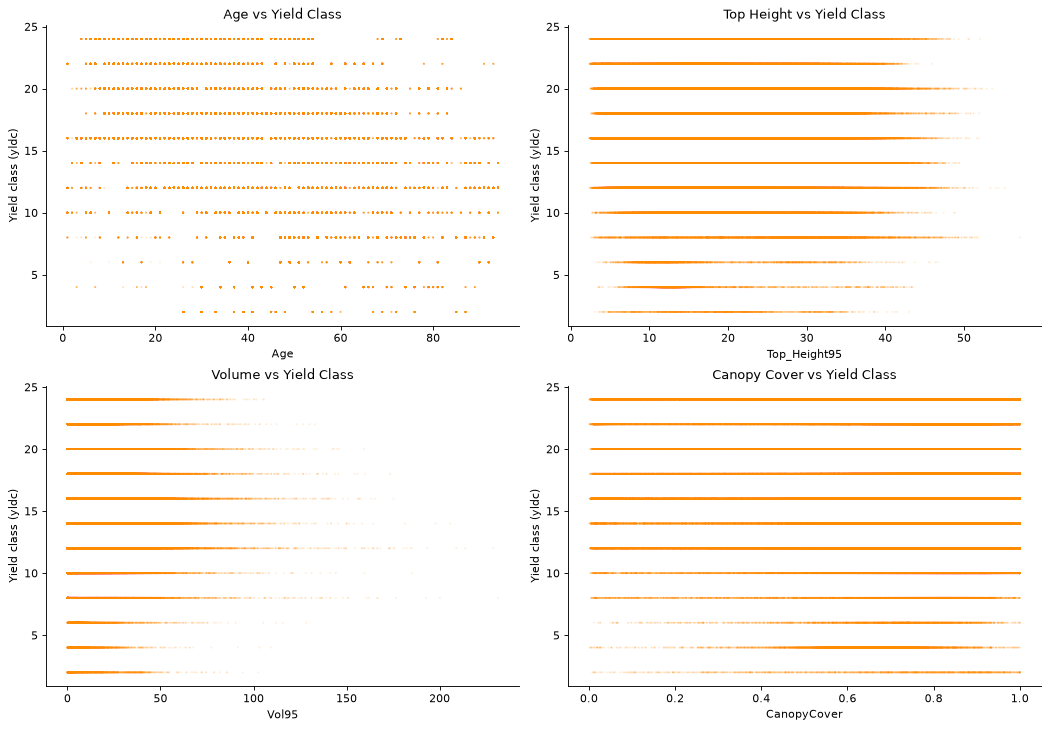

In [36]:
# Purpose: Plot assigned yield class against age and structural variables.
# Key logic: Low alpha makes dense areas darker without drawing an expensive density model.

# yldc vs age, height, volume (four-year cleaned data, yldc > 0)
d4_yc = d4[d4["yldc"].gt(0)].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout="constrained")
pairs_yc = [
    ("Age", "yldc", "Age vs Yield Class"),
    ("Top_Height95", "yldc", "Top Height vs Yield Class"),
    ("Vol95", "yldc", "Volume vs Yield Class"),
    ("CanopyCover", "yldc", "Canopy Cover vs Yield Class"),
]

for ax, (x, y, title) in zip(axes.flat, pairs_yc):
    sub = d4_yc[[x, y]].dropna()
    ax.scatter(sub[x], sub[y], s=3, alpha=0.15, color="darkorange", edgecolor="none")
    ax.set_xlabel(x)
    ax.set_ylabel("Yield class (yldc)")
    ax.set_title(title)

plt.show()


**Plot interpretation.** These panels show association, not causation. Horizontal bands are expected because `yldc` has a small number of assigned classes. Yield class should therefore be treated as a categorical or ordinal label rather than a continuous LiDAR measurement.


In [37]:
# Purpose: Compare yield class across thinning and planting-year groups.
# Key logic: These summaries describe association with management history; they do not show that yield class was caused by thinning.

# Yield class — does it change with thinning or planting year?
print("yldc by thinning status (Thin == 1 vs 0):")
print(d4_yc.groupby("Thin")["yldc"].describe().round(2))
print()
print("yldc correlation with key variables (Spearman):")
for col in ["Age", "Top_Height95", "Vol95", "CanopyCover", "plyr"]:
    sub = d4_yc[[col, "yldc"]].dropna()
    rho, pval = spearmanr(sub[col], sub["yldc"])
    print(f"  yldc ~ {col}: ρ={rho:.3f}  p={pval:.3e}")


yldc by thinning status (Thin == 1 vs 0):
         count   mean   std  min   25%   50%   75%   max
Thin                                                    
0.0   194048.0  15.43  4.86  2.0  12.0  16.0  18.0  24.0
1.0    93016.0  21.16  4.03  4.0  20.0  24.0  24.0  24.0

yldc correlation with key variables (Spearman):
  yldc ~ Age: ρ=-0.338  p=0.000e+00
  yldc ~ Top_Height95: ρ=0.036  p=5.822e-84
  yldc ~ Vol95: ρ=-0.069  p=3.089e-299


  yldc ~ CanopyCover: ρ=0.070  p=1.163e-304
  yldc ~ plyr: ρ=0.370  p=0.000e+00


**Interpretation.** Any association with planting period or thinning describes how management categories are distributed; it does not make yldc a measured growth response.

### Summary — Yield Class
- `yldc` is **constant within every repeated plot** in this dataset. It behaves as a fixed plot-level label rather than a measurement repeated independently in each survey.
- It correlates with volume and height but the relationship is weak at the plot level — yield class is a species-stand type category, not a precise growth prediction.
- Yield class behaves like a **categorical management label**: assigned at planting, used to select volume/growth equations, and not independently measured from LiDAR.
- For PINN/Chapman-Richards: yield class could be a useful conditioning variable (sets growth trajectory class) but should not be used as a continuous target.
- For Random Forest/XGBoost: yield class is a legitimate categorical feature, but be aware of leakage if used alongside `Vol95` (both derived from the same equations).


---
## 7. Wind Hazard Class and Thinning


### 7a. Wind Hazard Class (`whcl`)

`whcl` is a sub-compartment wind-hazard classification linked to management decisions. It is not a raw LiDAR measurement and is excluded from baseline models below.
It is a categorical integer (0 = unclassified, 1 = very low, …, 6 = very high wind hazard)
derived from terrain and topographic exposure.


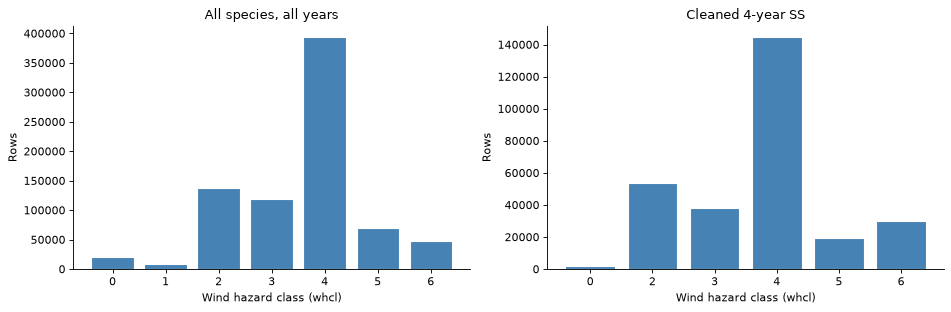

In [38]:
# Purpose: Compare wind-hazard class frequencies before and after cleaning.
# Key logic: Side-by-side counts show whether the cleaning funnel changes the representation of hazard classes.

# Distribution in the full dataset and in cleaned 4-year SS data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (dat, title) in zip(axes, [(df, "All species, all years"), (d4, "Cleaned 4-year SS")]):
    counts = dat["whcl"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Wind hazard class (whcl)")
    ax.set_ylabel("Rows")
    ax.set_title(title)

plt.tight_layout()
plt.show()


**Interpretation.** Differences between panels reveal whether cleaning disproportionately removes particular hazard classes and therefore changes environmental representation.

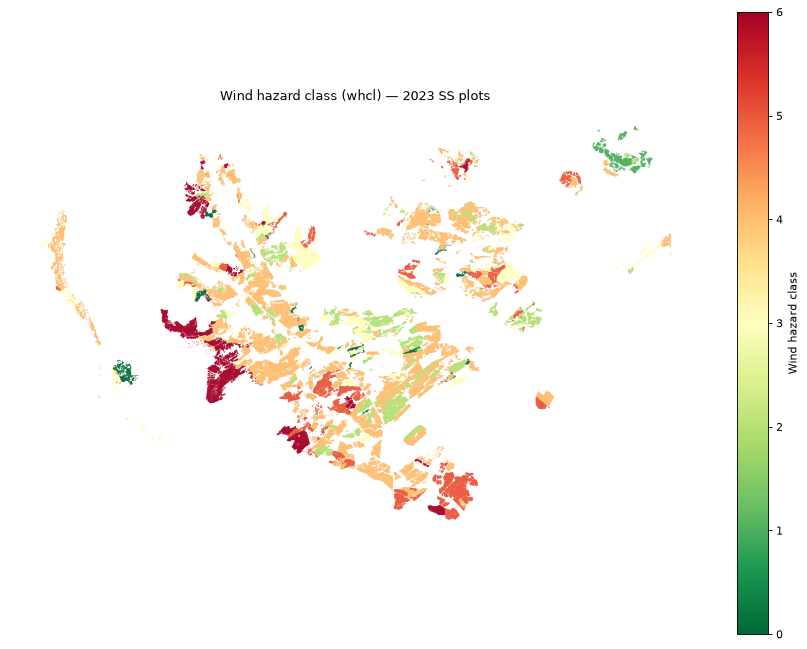

In [39]:
# Purpose: Map wind-hazard classes for 2023 Sitka spruce records.
# Key logic: A shared categorical colour scale highlights spatial zoning; class 0 should be interpreted as unclassified.

# whcl spatial map — 2023 SS plots
# Reuse spatial_data loaded earlier instead of reading the GeoPackage again.
gdf_ss_2023 = spatial_data.loc[
    spatial_data["LiDAR_year"].eq(2023)
    & spatial_data["spis"].eq("SS")
].copy()

# One point per polygon is enough to show the spatial pattern and plots quickly.
whcl_points = gdf_ss_2023.geometry.representative_point()

fig, axis = plt.subplots(figsize=(10, 8), layout="constrained")
points = axis.scatter(
    whcl_points.x,
    whcl_points.y,
    c=gdf_ss_2023["whcl"],
    cmap="RdYlGn_r",
    s=0.5,
    linewidths=0,
    rasterized=True,
)
fig.colorbar(points, ax=axis, label="Wind hazard class")
axis.set_title("Wind hazard class (whcl) — 2023 SS plots")
axis.set_axis_off()
axis.set_aspect("equal")
plt.show()


**Map interpretation.** This map shows whether wind-hazard classes form coherent geographic zones. It supports using `whcl` as a spatial environmental predictor, but class 0 should remain excluded or treated as unknown rather than interpreted as no wind hazard.


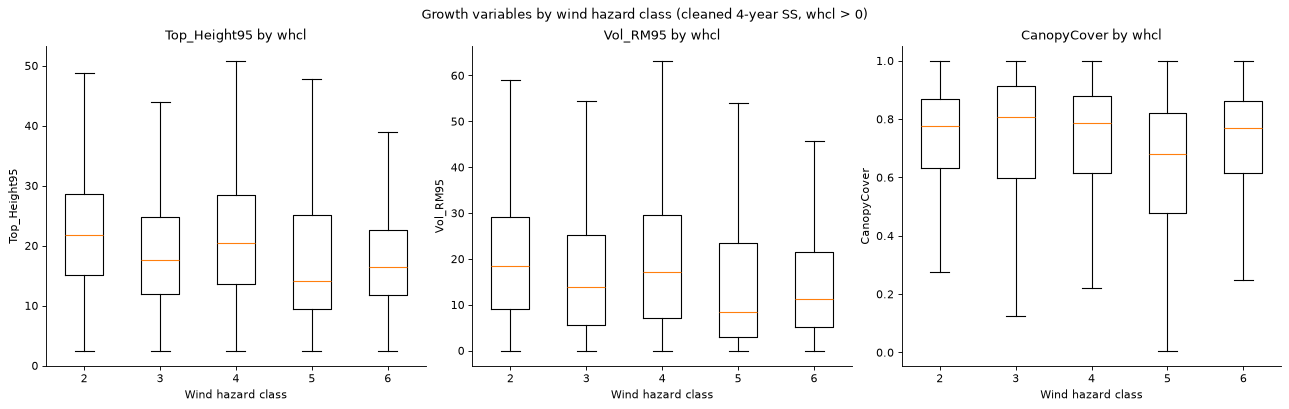

whcl ~ Top_Height95: ρ = -0.098, p = 0.000e+00, n = 285,480
whcl ~ Vol_RM95    : ρ = -0.093, p = 0.000e+00, n = 285,480


In [40]:
# Purpose: Compare structural variables across classified wind-hazard classes.
# Key logic: Boxplots show medians and interquartile ranges; pairwise dropna prevents missing values from invalidating Spearman correlations.

# whcl vs growth variables — exclude whcl == 0 as unclassified
d4_w = d4[d4["whcl"].gt(0)].copy()

whcl_values = sorted(d4_w["whcl"].dropna().unique())

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    layout="constrained",
)

for ax, col in zip(
    axes,
    ["Top_Height95", "Vol_RM95", "CanopyCover"],
):
    groups = [
        d4_w.loc[d4_w["whcl"].eq(w), col].dropna()
        for w in whcl_values
    ]

    ax.boxplot(
        groups,
        tick_labels=[str(w) for w in whcl_values],
        showfliers=False,
    )
    ax.set_xlabel("Wind hazard class")
    ax.set_ylabel(col)
    ax.set_title(f"{col} by whcl")

fig.suptitle(
    "Growth variables by wind hazard class "
    "(cleaned 4-year SS, whcl > 0)",
    fontsize=12,
)

plt.show()

# Spearman correlations with pairwise missing-value removal
for col in ["Top_Height95", "Vol_RM95"]:
    valid = d4_w[["whcl", col]].dropna()

    rho, pval = spearmanr(valid["whcl"], valid[col])

    print(
        f"whcl ~ {col:<12}: "
        f"ρ = {rho:.3f}, p = {pval:.3e}, n = {len(valid):,}"
    )


**Plot interpretation.** The centre line of each box is the median and the box contains the middle 50% of observations. Overlapping boxes imply weak separation between hazard classes. Because every plot appears in several years, the printed correlations are descriptive and their p-values should not be treated as independent-observation tests.


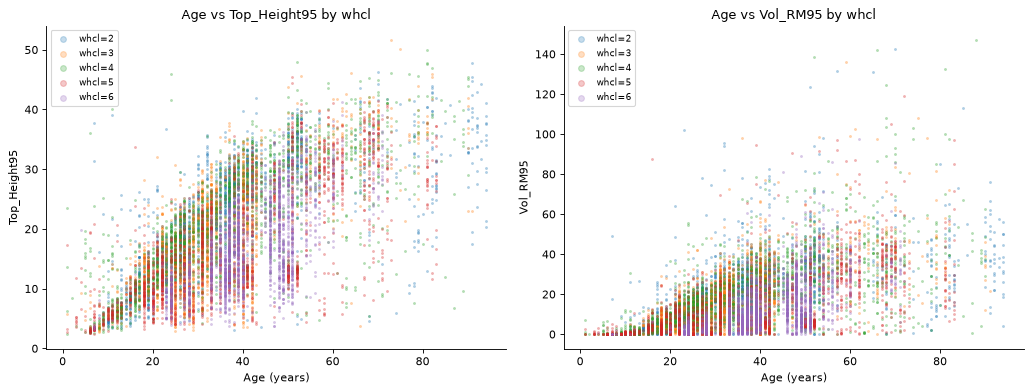

In [41]:
# Purpose: Check whether apparent hazard-class differences persist across age groups.
# Key logic: Age grouping reduces the obvious confounding caused by older stands generally being taller.

# whcl vs age — does wind exposure affect apparent growth rate?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ["Top_Height95", "Vol_RM95"]):
    for w in sorted(d4_w["whcl"].unique()):
        sub = d4_w[d4_w["whcl"].eq(w)].sample(min(2000, len(d4_w[d4_w["whcl"].eq(w)])), random_state=42)
        ax.scatter(sub["Age"], sub[col], s=3, alpha=0.25, label=f"whcl={w}")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel(col)
    ax.set_title(f"Age vs {col} by whcl")
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()


**Interpretation.** Parallel age patterns with vertical separation suggest an association beyond age; overlapping patterns suggest that much of the raw difference was age composition.

### 7b. Thinning

`Thin` encodes whether a plot was thinned (1.0) or unthinned (0.0).
`last_thinn` records the year of the most recent thinning; `next_thin_` the planned year.


#### Testing the `whcl > 4` no-thin rule

`whcl` is treated here as a sub-compartment wind-hazard/management class, not as
a raw LiDAR measurement. The first analysis checks whether records in classes 5
and 6 are almost always assigned `Thin == 0`. This tests whether the expected
management rule appears in the supplied data; it does not test whether the rule
is ecologically correct.

Record counts by wind-hazard class


,Not thinned,Thinned
whcl,,
2,22380,31120
3,29740,8492
4,92704,51836
5,17836,1552
6,29804,16


Percentage within each wind-hazard class


,Not thinned,Thinned
whcl,,
2,41.8,58.2
3,77.8,22.2
4,64.1,35.9
5,92.0,8.0
6,99.9,0.1


Records with whcl > 4: 49,208
Thinned records with whcl > 4: 1,568 (3.19%)
Distinct thinned plots with whcl > 4: 392


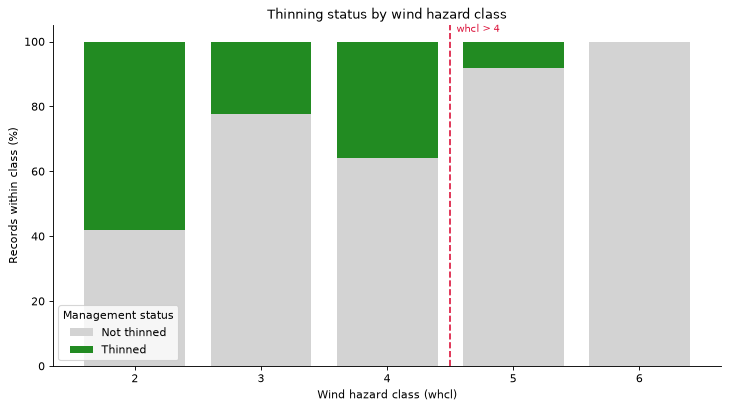

In [42]:
# Purpose: Test whether the whcl>4 no-thin management rule is visible in the cleaned data.
# Key logic: The crosstab is converted to within-class percentages; distinct exception plots are counted separately from repeated survey rows.

# Keep classified records with an explicit thinned/not-thinned value.
thin_analysis = d4[
    d4["whcl"].gt(0)
    & d4["Thin"].isin([0.0, 1.0])
].copy()

# Count records in every wind-hazard and thinning combination.
thin_by_whcl = pd.crosstab(
    thin_analysis["whcl"],
    thin_analysis["Thin"],
)
thin_by_whcl.columns = ["Not thinned", "Thinned"]

# Convert row counts to percentages within each whcl class.
thin_percent = thin_by_whcl.div(
    thin_by_whcl.sum(axis=1),
    axis=0,
).mul(100)

print("Record counts by wind-hazard class")
display(thin_by_whcl)

print("Percentage within each wind-hazard class")
display(thin_percent.round(1))

# Directly audit the proposed rule: whcl > 4 should normally mean no thinning.
high_hazard = thin_analysis[thin_analysis["whcl"].gt(4)]
exception_rows = high_hazard[high_hazard["Thin"].eq(1.0)]

print(f"Records with whcl > 4: {len(high_hazard):,}")
print(
    "Thinned records with whcl > 4: "
    f"{len(exception_rows):,} "
    f"({len(exception_rows) / len(high_hazard) * 100:.2f}%)"
)
print(
    "Distinct thinned plots with whcl > 4: "
    f"{exception_rows['identification'].nunique():,}"
)

# Plot percentages rather than counts because whcl classes have different sizes.
fig, axis = plt.subplots(figsize=(9, 5), layout="constrained")
thin_percent.plot(
    kind="bar",
    stacked=True,
    color=["lightgrey", "forestgreen"],
    width=0.8,
    ax=axis,
)
axis.axvline(2.5, color="crimson", linestyle="--", linewidth=1.5)
axis.text(2.55, 103, "whcl > 4", color="crimson", fontsize=9)
axis.set_xlabel("Wind hazard class (whcl)")
axis.set_ylabel("Records within class (%)")
axis.set_title("Thinning status by wind hazard class")
axis.legend(title="Management status", loc="lower left")
axis.tick_params(axis="x", rotation=0)
plt.show()

**Interpretation.** Classes 5 and 6 should have a very small green section if the
`whcl > 4` no-thin rule is represented in the data. Any thinned records above the
threshold are exceptions worth checking with the data provider. Because `Thin`
and `whcl` are repeated plot-level attributes, the record counts include the same
plot in several survey years; the distinct-plot count is the relevant count of
management exceptions.

In [43]:
# Purpose: Summarise thinning status overall and by survey year.
# Key logic: normalize=True converts counts to proportions within each survey year.

# Thinning rates overall and by LiDAR year
print("Overall thinning rate:")
print(d4["Thin"].value_counts(normalize=True).mul(100).round(2).to_string())
print()
print("Thinning rate by LiDAR year (cleaned 4-year SS):")
thin_by_year = d4.groupby("LiDAR_year")["Thin"].mean().mul(100).round(2)
print(thin_by_year.to_string())


Overall thinning rate:
Thin
0.0    67.6
1.0    32.4

Thinning rate by LiDAR year (cleaned 4-year SS):
LiDAR_year
2008    32.4
2012    32.4
2021    32.4
2023    32.4


**Interpretation.** Survey-year differences may reflect management timing or repeated static labels. Because Thin is fixed within plots here, do not interpret these proportions automatically as thinning events occurring between surveys.

In [44]:
# Purpose: Inspect the ranges and missing-code behaviour of thinning-year fields.
# Key logic: Zeros are reported separately because they may mean never thinned or unknown.

# last_thinn and next_thin_ — what do they look like?
print("last_thinn (year of last thinning) — excluding 0:")
valid_lt = d4.loc[d4["last_thinn"].gt(0), "last_thinn"]
print(valid_lt.describe().round(0))
print(f"Rows with last_thinn == 0 (never thinned or unknown): {d4['last_thinn'].eq(0).sum():,}")
print()
print("next_thin_ (planned thinning year) — excluding 0:")
valid_nt = d4.loc[d4["next_thin_"].gt(0), "next_thin_"]
print(valid_nt.describe().round(0))
print(f"Rows with next_thin_ == 0: {d4['next_thin_'].eq(0).sum():,}")


last_thinn (year of last thinning) — excluding 0:
count    93016.0
mean      2017.0
std          7.0
min       2000.0
25%       2011.0
50%       2020.0
75%       2023.0
max       2026.0
Name: last_thinn, dtype: float64
Rows with last_thinn == 0 (never thinned or unknown): 194,048

next_thin_ (planned thinning year) — excluding 0:
count    279316.0
mean       2026.0
std           1.0
min        2026.0
25%        2026.0
50%        2026.0
75%        2026.0
max        2034.0
Name: next_thin_, dtype: float64
Rows with next_thin_ == 0: 7,748


**Interpretation.** The zero code remains ambiguous until confirmed by the provider. Time-since-thinning should be derived only after distinguishing never-thinned from unknown records.

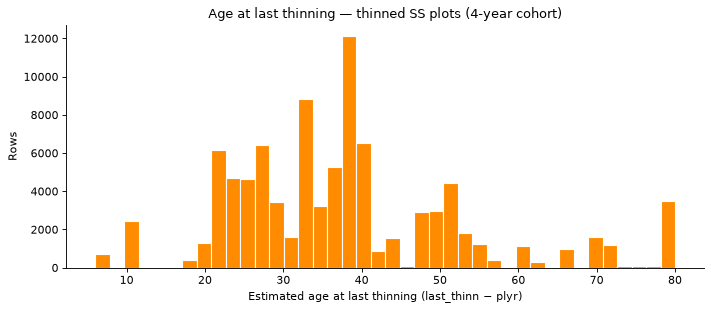

count    93016.0
mean        38.0
std         15.1
min          6.0
25%         27.0
50%         37.0
75%         43.0
max         80.0
Name: age_at_thinning, dtype: float64


In [45]:
# Purpose: Derive stand age when the most recent thinning occurred.
# Key logic: Subtracting planting year from last-thinning year is meaningful only where both dates are valid.

# Age at time of last thinning — does thinning happen at a consistent age?
d4_thinned = d4[d4["Thin"].eq(1.0) & d4["last_thinn"].gt(0)].copy()
d4_thinned["age_at_thinning"] = d4_thinned["last_thinn"] - d4_thinned["plyr"]

fig, ax = plt.subplots(figsize=(9, 4))
ages_th = d4_thinned["age_at_thinning"].clip(0, 80)
ax.hist(ages_th, bins=40, color="darkorange", edgecolor="white")
ax.set_xlabel("Estimated age at last thinning (last_thinn − plyr)")
ax.set_ylabel("Rows")
ax.set_title("Age at last thinning — thinned SS plots (4-year cohort)")
plt.tight_layout()
plt.show()

print(d4_thinned["age_at_thinning"].clip(0, 80).describe().round(1))


**Interpretation.** A biologically plausible concentration supports the date fields, while negative or extreme ages would reveal inconsistent management dates.

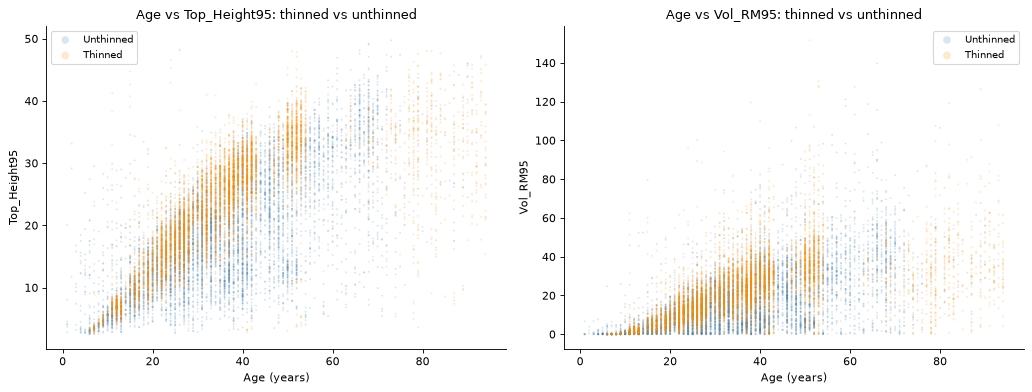

In [46]:
# Purpose: Compare height and volume between management groups at similar ages.
# Key logic: Age bins reduce, but do not eliminate, confounding between management status and stand development.

# Thinned vs unthinned: height and volume at comparable ages
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ["Top_Height95", "Vol_RM95"]):
    for thin_val, label, colour in [(0.0, "Unthinned", "steelblue"), (1.0, "Thinned", "darkorange")]:
        sub = d4[d4["Thin"].eq(thin_val)].sample(min(8000, (d4["Thin"].eq(thin_val)).sum()), random_state=42)
        ax.scatter(sub["Age"], sub[col], s=3, alpha=0.2, color=colour, label=label, edgecolor="none")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel(col)
    ax.set_title(f"Age vs {col}: thinned vs unthinned")
    ax.legend(markerscale=4, fontsize=9)

plt.tight_layout()
plt.show()


**Interpretation.** Separation between groups is descriptive. Age binning improves comparability but does not control yield class, hazard, block, or time since thinning.

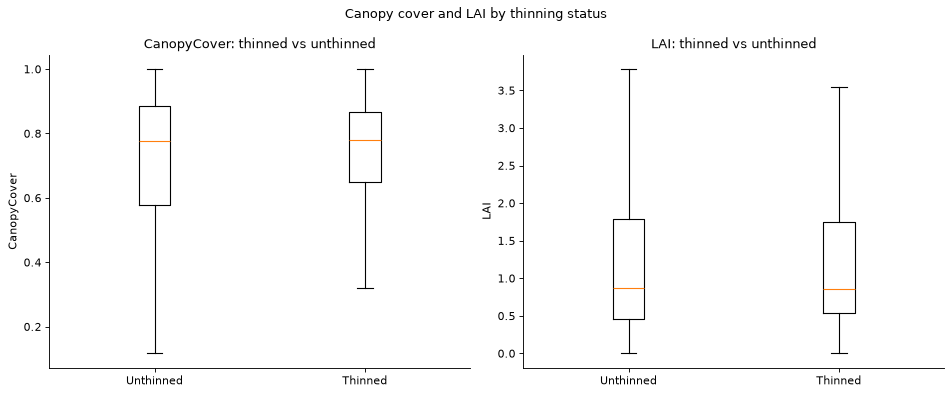

      CanopyCover    LAI
Thin                    
0.0         0.696  2.003
1.0         0.728  1.811


In [47]:
# Purpose: Compare canopy structure between thinned and unthinned records.
# Key logic: Differences may depend strongly on time since thinning, which is not controlled in a raw boxplot.

# Canopy cover and LAI response to thinning
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ["CanopyCover", "LAI"]):
    groups = [d4.loc[d4["Thin"].eq(0.0), col].dropna(), d4.loc[d4["Thin"].eq(1.0), col].dropna()]
    ax.boxplot(groups, tick_labels=["Unthinned", "Thinned"], showfliers=False)
    ax.set_ylabel(col)
    ax.set_title(f"{col}: thinned vs unthinned")

plt.suptitle("Canopy cover and LAI by thinning status", fontsize=12)
plt.tight_layout()
plt.show()

# Means
print(d4.groupby("Thin")[["CanopyCover", "LAI"]].mean().round(3))


**Interpretation.** Lower canopy measures in thinned stands are plausible shortly after treatment, but recovery time and non-random treatment assignment prevent a causal interpretation.

Thinning rate by wind hazard class:
      Unthinned  Thinned  pct_thinned
whcl                                 
2         22380    31120         58.2
3         29740     8492         22.2
4         92704    51836         35.9
5         17836     1552          8.0
6         29804       16          0.1


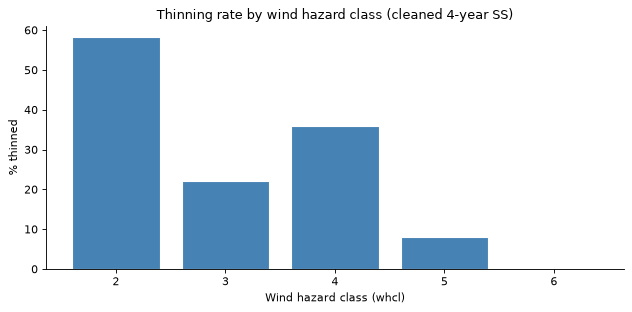

In [48]:
# Purpose: Tabulate the association between wind-hazard classification and thinning status.
# Key logic: Row percentages answer what fraction is thinned within each hazard class.

# whcl × Thin cross-tab — does wind exposure drive thinning decisions?
cross = (
    d4[d4["whcl"].gt(0)]
    .groupby(["whcl", "Thin"])
    .size()
    .unstack(fill_value=0)
)
cross.columns = ["Unthinned", "Thinned"]
cross["pct_thinned"] = (cross["Thinned"] / cross.sum(axis=1) * 100).round(1)
print("Thinning rate by wind hazard class:")
print(cross.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cross.index.astype(str), cross["pct_thinned"], color="steelblue", edgecolor="white")
ax.set_xlabel("Wind hazard class (whcl)")
ax.set_ylabel("% thinned")
ax.set_title("Thinning rate by wind hazard class (cleaned 4-year SS)")
plt.tight_layout()
plt.show()


**Interpretation.** A sharp decline in thinning above class 4 supports the stated management rule and also shows that whcl and Thin are not independent predictors.

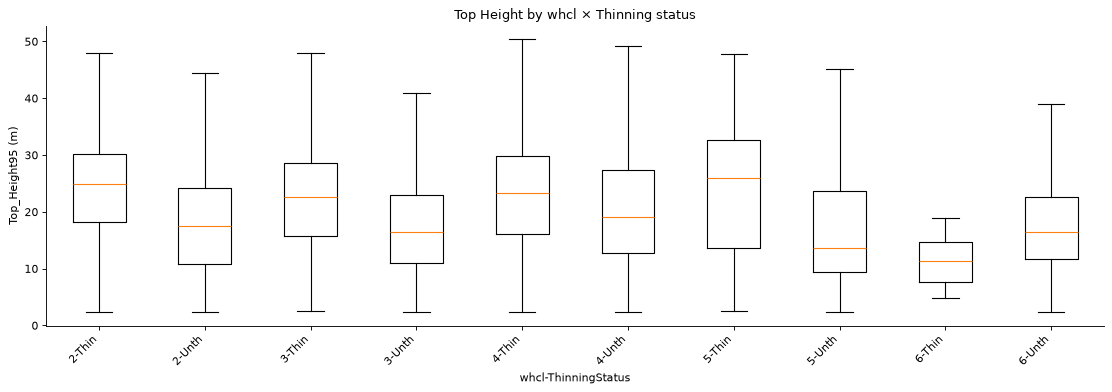

In [49]:
# Purpose: Compare top height jointly across wind-hazard and thinning groups.
# Key logic: Separate boxes within each class make a possible management-by-hazard interaction visible.

# whcl × Thin interaction on Top_Height95 — two-way boxplot
d4_w2 = d4[d4["whcl"].gt(0)].copy()
d4_w2["group"] = d4_w2["whcl"].astype(str) + "-" + d4_w2["Thin"].map({0.0:"Unth", 1.0:"Thin"})
group_order = sorted(d4_w2["group"].unique())

fig, ax = plt.subplots(figsize=(14, 5))
groups = [d4_w2.loc[d4_w2["group"].eq(g), "Top_Height95"].dropna() for g in group_order]
ax.boxplot(groups, tick_labels=group_order, showfliers=False)
ax.set_xlabel("whcl-ThinningStatus")
ax.set_ylabel("Top_Height95 (m)")
ax.set_title("Top Height by whcl × Thinning status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Interpretation.** Differences between thinning groups that change across hazard classes suggest interaction or selection effects. They do not isolate the biological effect of thinning.

In [50]:
# Purpose: Inspect whether p1-p5 behave like a small lookup table.
# Key logic: A small set of repeated unique values supports treating them as model parameters rather than field measurements.

# p1-p5: confirm they are lookup parameters, not independent measurements
p_cols = [c for c in ["p1","p2","p3","p4","p5"] if c in d4.columns]
if p_cols:
    for c in p_cols:
        uniq = d4[c].dropna().nunique()
        vals = sorted(d4[c].dropna().unique())
        print(f"{c}: {uniq} unique values → {[round(v,5) for v in vals]}")
    print("\n→ p1–p5 are species-level lookup parameters. Exclude from model inputs.")


p1: 6 unique values → [np.float64(11.32377), np.float64(12.92795), np.float64(14.13048), np.float64(14.38089), np.float64(14.42068), np.float64(14.85586)]
p2: 6 unique values → [np.float64(1.1446), np.float64(1.46881), np.float64(1.47388), np.float64(1.71977), np.float64(1.77814), np.float64(2.83421)]
p3: 4 unique values → [np.float64(-1.14229), np.float64(-0.45628), np.float64(-0.23739), np.float64(0.0)]
p4: 6 unique values → [np.float64(0.02213), np.float64(0.02378), np.float64(0.02518), np.float64(0.0284), np.float64(0.03507), np.float64(0.04076)]
p5: 6 unique values → [np.float64(1.06171), np.float64(1.11832), np.float64(1.25488), np.float64(1.32104), np.float64(1.49314), np.float64(1.92368)]

→ p1–p5 are species-level lookup parameters. Exclude from model inputs.


**Interpretation.** Few repeated values indicate lookup parameters. Their exact model and equation still require confirmation from the data provider.

#### Thinned versus unthinned growth measurements

A raw comparison can be misleading because thinned and unthinned stands differ in
age, yield class, wind hazard and location. The following figure therefore shows
medians within five-year age bands. The table then compares thinned and unthinned
records only within strata sharing survey year, five-year age band, yield class and
wind-hazard class. This reduces obvious confounding but remains observational; it
does not estimate a causal thinning effect.

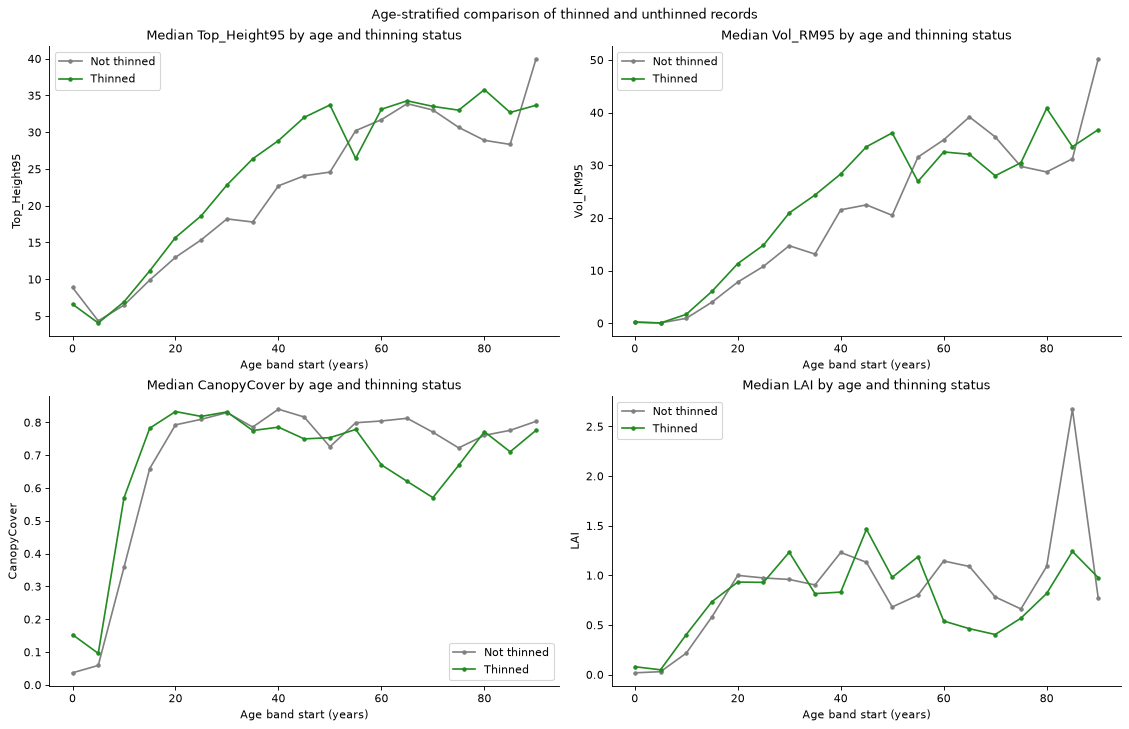

Within-stratum difference: thinned minus not thinned


,outcome,comparable_strata,median_difference,mean_difference
0,Top_Height95,220,0.730,1.698
1,Vol_RM95,220,0.355,0.912
2,CanopyCover,220,-0.017,-0.005
3,LAI,220,-0.051,-0.231


In [51]:
# Purpose: Compare thinning groups by age and within matched management/environment strata.
# Key logic: unstack places Thin=0 and Thin=1 in separate columns; subtracting them gives thinned minus unthinned within the same stratum.

# Five-year age groups make stands of broadly similar age easier to compare.
thin_analysis["age_band"] = (
    np.floor(thin_analysis["Age"] / 5) * 5
).astype(int)

outcomes = ["Top_Height95", "Vol_RM95", "CanopyCover", "LAI"]
status_labels = {0.0: "Not thinned", 1.0: "Thinned"}
colors = {0.0: "grey", 1.0: "forestgreen"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), layout="constrained")

for axis, outcome in zip(axes.flat, outcomes):
    # Calculate one median for each age band and thinning status.
    age_medians = (
        thin_analysis.groupby(["age_band", "Thin"])[outcome]
        .median()
        .reset_index()
    )

    for thin_value in [0.0, 1.0]:
        group = age_medians[age_medians["Thin"].eq(thin_value)]
        axis.plot(
            group["age_band"],
            group[outcome],
            marker="o",
            markersize=3,
            linewidth=1.5,
            color=colors[thin_value],
            label=status_labels[thin_value],
        )

    axis.set_xlabel("Age band start (years)")
    axis.set_ylabel(outcome)
    axis.set_title(f"Median {outcome} by age and thinning status")
    axis.legend()

fig.suptitle("Age-stratified comparison of thinned and unthinned records")
plt.show()

# Compare like with like more closely using four stratification variables.
strata = ["LiDAR_year", "age_band", "yldc", "whcl"]
adjusted_results = []

for outcome in outcomes:
    stratum_medians = (
        thin_analysis.groupby(strata + ["Thin"])[outcome]
        .median()
        .unstack("Thin")
        .dropna()
    )

    # Difference is thinned minus not-thinned within the same stratum.
    differences = stratum_medians[1.0] - stratum_medians[0.0]
    adjusted_results.append({
        "outcome": outcome,
        "comparable_strata": len(differences),
        "median_difference": differences.median(),
        "mean_difference": differences.mean(),
    })

adjusted_summary = pd.DataFrame(adjusted_results)
print("Within-stratum difference: thinned minus not thinned")
display(adjusted_summary.round(3))

**Interpretation.** A negative difference means the thinned records have a lower
value than comparable unthinned records; a positive difference means they have a
higher value. Top height is the strongest primary comparison. Interpret volume
carefully because `Vol_RM95` is derived from height, area and canopy cover, so a
volume difference is not independent evidence of a thinning effect. Lower canopy cover or LAI after thinning would be biologically plausible,
but the time elapsed since thinning should be included before drawing a strong
conclusion.

These rows are repeated measurements of spatial plots, so ordinary p-values would
overstate the effective sample size. A later modelling analysis should use plot
groups, spatial blocks, and—if reliable—`LiDAR_year - last_thinn` as time since
thinning.

### Summary — Wind Hazard Class and Thinning

- `whcl` is a sub-compartment wind-hazard/management classification, not a raw
  LiDAR measurement. It should not be described as independent of management.
- The proposed no-thin rule is strongly visible above class 4: only 2.63% of
  records with `whcl > 4` are marked as thinned. These correspond to 312 distinct
  plots and should be checked as possible exceptions or coding differences.
- Thinning is most common in class 2 and less common in classes 3–4; class 6 is
  almost entirely unthinned. This pattern is consistent with wind-risk rules
  influencing management decisions.
- Within survey-year, five-year age, yield-class and wind-hazard strata, thinned
  records have slightly higher median top height, slightly lower canopy cover and
  slightly lower LAI. These are observational associations, not causal estimates.
- `Vol_RM95` is derived using height, area and canopy cover, so its difference
  between thinning groups is not independent evidence of a thinning effect.
- `whcl` and `Thin` should not be interpreted as independent environmental
  predictors. A stronger later model would separate continuous terrain/wind
  exposure from the management decision.
- If `last_thinn` is reliable, `LiDAR_year - last_thinn` should be tested as time
  since thinning because canopy and LAI responses will change as the stand recovers.

Main results:
- Only 2.63% of records with whcl > 4 are thinned.
- These exceptions represent 312 distinct plots. 
- Class 6 is 99.9% unthinned.
Within comparable strata, thinned records have:
- 0.72 m higher median Top_Height95;
- slightly higher derived `Vol_RM95` of about 3.57% in the matched-strata median comparison;
- 0.018 lower canopy cover;
- 0.046 lower LAI.

---
## 8. Relationship Analysis for Modelling


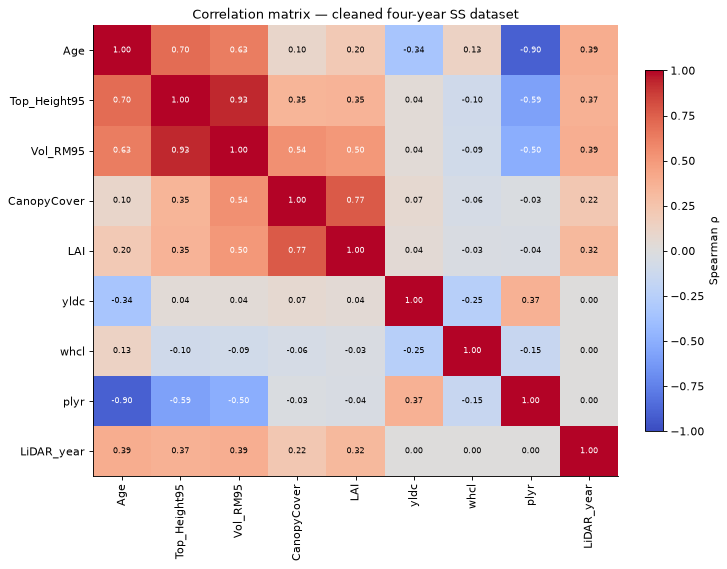

In [52]:
# Purpose: Summarise monotonic relationships among candidate modelling variables.
# Key logic: Spearman correlation uses ranks and is less sensitive to non-linear scaling and extreme values than Pearson correlation.

# Correlation matrix — cleaned four-year SS data
model_vars = ["Age", "Top_Height95", "Vol_RM95", "CanopyCover", "LAI",
              "yldc", "whcl", "plyr", "LiDAR_year"]
d4_model = d4[model_vars].replace(0, np.nan)  # yldc 0 = unknown

corr = d4_model.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(model_vars)))
ax.set_xticklabels(model_vars, rotation=90)
ax.set_yticks(range(len(model_vars)))
ax.set_yticklabels(model_vars)
for r in range(len(model_vars)):
    for c in range(len(model_vars)):
        ax.text(c, r, f"{corr.iloc[r,c]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[r,c]) > 0.5 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman ρ")
ax.set_title("Correlation matrix — cleaned four-year SS dataset")
plt.show()


**Plot interpretation.** Values near +1 or −1 indicate strong monotonic relationships; values near zero indicate weak relationships. Very high correlations between derived and source variables warn about redundant predictors or target leakage. Correlation does not show which variable causes another.


In [53]:
# Purpose: Document which fields are measured, recorded, derived, or unsuitable.
# Key logic: This table is a modelling safeguard against exact duplication and target leakage.

# Variable dependency summary
dependency_summary = pd.DataFrame([
    {"variable": "Age",          "type": "derived",    "note": "= LiDAR_year − plyr. Exact derivation — not independent."},
    {"variable": "Top_Height95", "type": "derived from LiDAR", "note": "= elev_percentile_95th × 1.1. Primary top-height target."},
    {"variable": "Top_Height99", "type": "derived from LiDAR", "note": "= elev_percentile_99th. Lower than Top_Height95 in ~25% of rows — use with caution."},
    {"variable": "Vol95",        "type": "derived",    "note": "= (g1 × Top_Height95^g3) × area_ha × CanopyCover. Leaks height target."},
    {"variable": "Vol99",        "type": "derived",    "note": "= (g1 × Top_Height99^g3) × area_ha × CanopyCover. Alternative height-derived volume."},
    {"variable": "Vol_RM95",     "type": "derived",    "note": "= (-35.8733 + 5.3486 × Top_Height95^1.5424) × area_ha × CanopyCover. Generic volume equation, not running mean."},
    {"variable": "GapFraction",  "type": "LiDAR-derived", "note": "Redundant canopy openness measure; do not use with CanopyCover without checking collinearity."},
    {"variable": "LAI",          "type": "LiDAR-derived", "note": "Derived from LiDAR gap/return information. Ceiling near 5.5."},
    {"variable": "CanopyCover",  "type": "LiDAR-derived", "note": "Structural LiDAR measurement used as one baseline canopy predictor."},
    {"variable": "yldc",         "type": "recorded label", "note": "Assigned FC Yield Class from FR inventory; fixed within cleaned repeated plots."},
    {"variable": "GYCspec95/99", "type": "derived",    "note": "Chapman-Richards rearrangement using height, age and p1–p5. Exclude from top-height predictors."},
    {"variable": "whcl",         "type": "management-linked", "note": "FR windthrow hazard class linked to thinning policy; audit/sensitivity variable only."},
    {"variable": "plyr",         "type": "recorded",   "note": "Planting year from FR inventory. Determines Age."},
    {"variable": "spis",         "type": "recorded",   "note": "FR inventory species code used for Sitka spruce filtering."},
    {"variable": "Species",      "type": "lookup",     "note": "Species name resolved from SPIS_RF; disagrees with spis in many rows, so use only as cross-check."},
    {"variable": "g1, g3",       "type": "lookup coefficients", "note": "Volume equation coefficients from ALS documentation. Not plot-level predictors."},
    {"variable": "p1–p5",        "type": "lookup coefficients", "note": "Chapman-Richards growth-model parameters. Not plot-level predictors."},
    {"variable": "Thin",         "type": "derived flag", "note": "= 1 when last_thinn != 0. Indicates known historical thinning, not necessarily recent thinning."},
    {"variable": "flyr",         "type": "recorded/unusable", "note": "Final/rotation year field, but all zeros in this extract. Drop."},
])
display(dependency_summary)

,variable,type,note
0,Age,derived,= LiDAR_year − plyr. Exact derivation — not independent.
1,Top_Height95,derived from LiDAR,= elev_percentile_95th × 1.1. Primary top-height target.
2,Top_Height99,derived from LiDAR,= elev_percentile_99th. Lower than Top_Height95 in ~25% of rows — use with caution.
3,Vol95,derived,= (g1 × Top_Height95^g3) × area_ha × CanopyCover. Leaks height target.
4,Vol99,derived,= (g1 × Top_Height99^g3) × area_ha × CanopyCover. Alternative height-derived volume.
5,Vol_RM95,derived,"= (-35.8733 + 5.3486 × Top_Height95^1.5424) × area_ha × CanopyCover. Generic volume equation, not running mean."
6,GapFraction,LiDAR-derived,Redundant canopy openness measure; do not use with CanopyCover without checking collinearity.
7,LAI,LiDAR-derived,Derived from LiDAR gap/return information. Ceiling near 5.5.
8,CanopyCover,LiDAR-derived,Structural LiDAR measurement used as one baseline canopy predictor.
9,yldc,recorded label,Assigned FC Yield Class from FR inventory; fixed within cleaned repeated plots.


**Interpretation.** Use this classification when selecting features: avoid including a derived target's source variables in ways that create leakage or exact redundancy.

In [54]:
# Purpose: Estimate multicollinearity among candidate continuous inputs.
# Key logic: Each variable is regressed on all others; VIF=1/(1-R²), so a high value means that variable is largely reconstructable from the rest.

# VIF — check multicollinearity among candidate model inputs
from numpy.linalg import lstsq

def vif(X):
    """Variance inflation factors for columns of X (DataFrame)."""
    X_arr = X.values
    vif_vals = {}
    for i, col in enumerate(X.columns):
        y = X_arr[:, i]
        others = np.delete(X_arr, i, axis=1)
        _, res, _, _ = lstsq(
            np.column_stack([np.ones(len(others)), others]), y, rcond=None
        )
        ss_tot = ((y - y.mean())**2).sum()
        r2 = 1 - (res[0] / ss_tot) if len(res) > 0 else 1.0
        vif_vals[col] = round(1 / (1 - r2) if r2 < 1 else np.inf, 2)
    return pd.Series(vif_vals, name="VIF")

# Select candidate inputs (exclude exact derivations)
vif_cols = ["Top_Height95", "CanopyCover", "LAI", "whcl", "Age"]
vif_data = d4[vif_cols].dropna()
print("VIF for candidate model inputs:")
print(vif(vif_data).to_string())


VIF for candidate model inputs:
Top_Height95    2.41
CanopyCover     1.40
LAI             1.20
whcl            1.07
Age             2.10


**VIF interpretation.** VIF measures how well each predictor can be reconstructed from the other predictors. A value near 1 indicates little redundancy; values above about 5 deserve investigation. `CanopyCover` and `LAI` should not both be used if their VIF values are high because LAI is derived from canopy gap information.


### Summary — Relationship Analysis
- `CanopyCover` and `LAI` are highly correlated (LAI is derived from gap fraction, which is the complement of canopy cover). Use one, not both.
- `Vol95`/`Vol99`/`Vol_RM95` are direct functions of height, area and canopy cover; `Vol95/99` also use species/thinning coefficients. Including both height and volume as model inputs creates leakage/collinearity. Choose based on modelling goal.
- `Age` is derived from `plyr` and `LiDAR_year`. Don't use all three simultaneously.
- `Top_Height95` and `CanopyCover` are correlated but not collinear — both carry information.
- A low VIF for `whcl` does not make it causally independent: it is linked to thinning policy and is excluded from baseline models.


---
## 9. Additional Investigations

Key questions that arise from the earlier analysis and are worth addressing before
committing to a modelling approach.


In [55]:
# Purpose: Count plots with strictly increasing versus non-increasing height trajectories.
# Key logic: apply checks whether every consecutive change within a plot is positive.

# 1. Are height trajectories monotonically increasing?
# A well-managed, undisturbed Sitka spruce stand should show monotonic height growth.
d4_sorted = d4.sort_values(["identification", "LiDAR_year"]).copy()
d4_sorted["height_change"] = d4_sorted.groupby("identification")["Top_Height95"].diff()

strictly_monotonic = (
    d4_sorted.dropna(subset=["height_change"])
    .groupby("identification")["height_change"]
    .apply(lambda x: (x > 0).all())
)
non_monotonic = (~strictly_monotonic).sum()
print(f"Plots with strictly increasing height (all surveys): {strictly_monotonic.sum():,}")
print(f"Plots with at least one height non-increase:         {non_monotonic:,} ({non_monotonic/len(strictly_monotonic)*100:.1f}%)")


Plots with strictly increasing height (all surveys): 64,121
Plots with at least one height non-increase:         7,645 (10.7%)


**Interpretation.** Non-increasing trajectories should be flagged for sensitivity analysis rather than automatically deleted, because genuine disturbance is relevant forest behaviour.

Plots with records in both 2012 and 2021: 71,766
Top_Height95 change 2012→2021 (9 years):
count    71766.00
mean         4.86
std          3.03
min        -36.05
25%          3.32
50%          5.25
75%          6.85
max         22.34
Name: Top_Height95, dtype: float64

Negative growth (height decrease 2012→2021): 2,652 plots


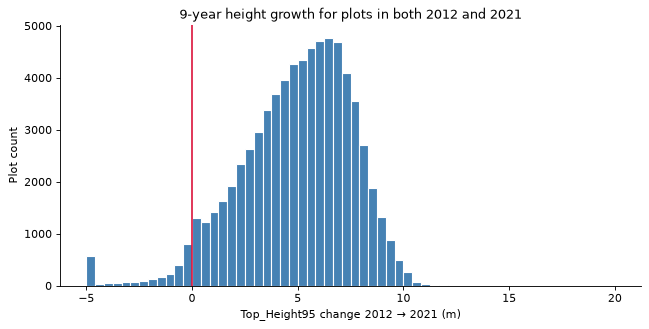

In [56]:
# Purpose: Describe nine-year height change for plots observed in both 2012 and 2021.
# Key logic: The intersection of plot IDs ensures that subtraction compares the same spatial plots.

# 2. Is there a consistent LiDAR-year calibration effect?
# Compare the same plots' measurements across surveys where we can.
# Use plots appearing in both 2012 and 2021 to check if 9-year growth is plausible.
both_12_21 = set(d4[d4["LiDAR_year"].eq(2012)]["identification"]) &              set(d4[d4["LiDAR_year"].eq(2021)]["identification"])

sub_12 = d4[d4["LiDAR_year"].eq(2012) & d4["identification"].isin(both_12_21)].set_index("identification")
sub_21 = d4[d4["LiDAR_year"].eq(2021) & d4["identification"].isin(both_12_21)].set_index("identification")

common = sub_12.index.intersection(sub_21.index)
height_growth = sub_21.loc[common, "Top_Height95"] - sub_12.loc[common, "Top_Height95"]

print(f"Plots with records in both 2012 and 2021: {len(common):,}")
print(f"Top_Height95 change 2012→2021 (9 years):")
print(height_growth.describe().round(2))
print(f"\nNegative growth (height decrease 2012→2021): {(height_growth < 0).sum():,} plots")

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.hist(height_growth.clip(-5, 20), bins=60, color="steelblue", edgecolor="white")
ax.axvline(0, color="crimson", linewidth=1.5)
ax.set_xlabel("Top_Height95 change 2012 → 2021 (m)")
ax.set_ylabel("Plot count")
ax.set_title("9-year height growth for plots in both 2012 and 2021")
plt.show()


**Interpretation.** Negative nine-year changes are unlikely to represent ordinary undisturbed growth and should be compared with thinning, storm, harvesting, and survey metadata.

In [57]:
# Purpose: Test whether mean top height differs among sub-compartment blocks.
# Key logic: One-way ANOVA compares group means, but its p-value does not measure effect size and repeated spatial observations violate simple independence.

# 3. Block-level variation — does blk explain variance beyond whcl?
# If blocks vary significantly in height at the same age, block is a useful random effect.
from scipy.stats import f_oneway

d4_blk = d4.copy()
d4_blk["age_group"] = pd.cut(d4_blk["Age"], bins=[0,15,25,35,45,60,200], right=False)

print("Top_Height95 variance decomposition:")
print(f"  Overall std: {d4_blk['Top_Height95'].std():.3f}")
print(f"  Std within blk groups: {d4_blk.groupby('blk')['Top_Height95'].std().mean():.3f}")

blocks = [grp["Top_Height95"].dropna() for _, grp in d4_blk.groupby("blk") if len(grp) > 30]
stat, pval = f_oneway(*blocks)
print(f"  One-way ANOVA across blocks: F={stat:.1f}  p={pval:.2e}")
print("  → Block explains significant variance: use blk as a stratification variable or random effect.")


Top_Height95 variance decomposition:
  Overall std: 9.274
  Std within blk groups: 7.692


  One-way ANOVA across blocks: F=2697.3  p=0.00e+00
  → Block explains significant variance: use blk as a stratification variable or random effect.


**ANOVA interpretation.** ANOVA tests whether all block mean heights are equal. With this very large dataset, a small p-value is expected even for modest differences. It should therefore be considered alongside the within-block variability and spatial validation, not used alone as proof that block causes height differences.


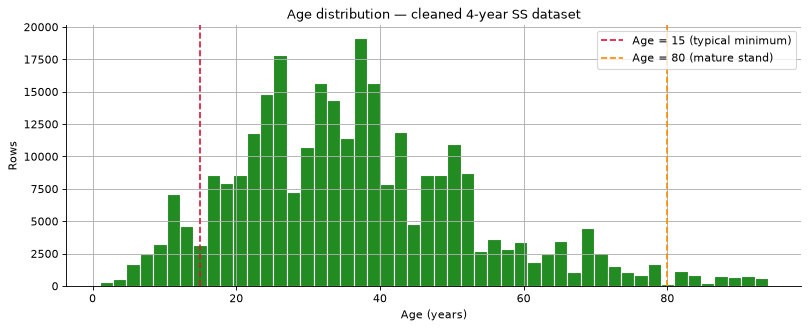

Age < 15 : 19,956 (7.0%)  — juvenile phase; CR curve may be less reliable here
Age > 80 : 5,054  (1.8%)  — mature; sparse data may inflate asymptote uncertainty


In [58]:
# Purpose: Check coverage of juvenile and mature stands for growth-curve estimation.
# Key logic: Sparse age tails make the early-growth rate and mature asymptote harder to estimate reliably.

# 4. Are very young and very old stands well-represented?
# Chapman-Richards needs data across the full age range.
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
d4["Age"].hist(bins=50, ax=ax, color="forestgreen", edgecolor="white")
ax.axvline(15, color="crimson", linestyle="--", linewidth=1.5, label="Age = 15 (typical minimum)")
ax.axvline(80, color="darkorange", linestyle="--", linewidth=1.5, label="Age = 80 (mature stand)")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Rows")
ax.set_title("Age distribution — cleaned 4-year SS dataset")
ax.legend()
plt.show()

young = d4["Age"].lt(15).sum()
old   = d4["Age"].gt(80).sum()
total = len(d4)
print(f"Age < 15 : {young:,} ({young/total*100:.1f}%)  — juvenile phase; CR curve may be less reliable here")
print(f"Age > 80 : {old:,}  ({old/total*100:.1f}%)  — mature; sparse data may inflate asymptote uncertainty")


In [ ]:
# Purpose: Check coverage of juvenile and mature stands for growth-curve estimation.
# Key logic: Sparse age tails make the early-growth rate and mature asymptote harder to estimate reliably.

# 4. Are very young and very old stands well-represented?
# Chapman-Richards needs data across the full age range.
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
d6["Age"].hist(bins=50, ax=ax, color="forestgreen", edgecolor="white")
ax.axvline(15, color="crimson", linestyle="--", linewidth=1.5, label="Age = 15 (typical minimum)")
ax.axvline(80, color="darkorange", linestyle="--", linewidth=1.5, label="Age = 80 (mature stand)")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Rows")
ax.set_title("Age distribution — cleaned 4-year SS dataset")
ax.legend()
plt.show()

young = d6["Age"].lt(15).sum()
old   = d6["Age"].gt(80).sum()
total = len(d6)
print(f"Age < 15 : {young:,} ({young/total*100:.1f}%)  — juvenile phase; CR curve may be less reliable here")
print(f"Age > 80 : {old:,}  ({old/total*100:.1f}%)  — mature; sparse data may inflate asymptote uncertainty")


**Interpretation.** A small juvenile sample weakens estimation of early growth, while a small mature sample weakens estimation of the Chapman–Richards asymptote.

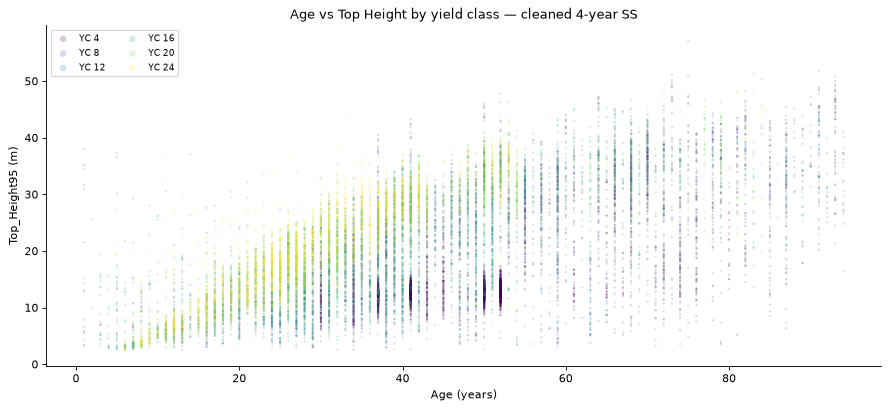

In [59]:
# Purpose: Visualise age-height relationships for major yield classes.
# Key logic: Sampling is used only for display speed; it does not reduce the modelling dataset.

# 5. Yield class × age: do different yield classes separate cleanly?
d4_yc = d4[d4["yldc"].gt(0)].copy()
yc_main = [yc for yc in [4, 8, 12, 16, 20, 24] if yc in d4_yc["yldc"].unique()]

fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
cmap = plt.get_cmap("viridis", len(yc_main))
for i, yc in enumerate(yc_main):
    sub = d4_yc[d4_yc["yldc"].eq(yc)].sample(min(3000, d4_yc["yldc"].eq(yc).sum()), random_state=42)
    ax.scatter(sub["Age"], sub["Top_Height95"], s=4, alpha=0.2,
               color=cmap(i), label=f"YC {yc}", edgecolor="none")

ax.set_xlabel("Age (years)")
ax.set_ylabel("Top_Height95 (m)")
ax.set_title("Age vs Top Height by yield class — cleaned 4-year SS")
ax.legend(markerscale=3, fontsize=8, ncol=2)
plt.show()


**Plot interpretation.** Separation between yield-class clouds suggests that yield class contains information about expected growth trajectory. Heavy overlap means it is not sufficient by itself. The sample is capped at 3,000 rows per class to keep the plot fast and readable; the modelling dataset is not sampled.


In [60]:
# Purpose: Summarise height changes across the unequal survey intervals.
# Key logic: unstack converts years into columns so each interval compares values from the same plot.

# 6. Spacing between surveys: is the 4-year cohort actually consistent?
# Verify that 2008→2012→2021→2023 gives consistent time gaps.
d4_wide = (
    d4.groupby(["identification", "LiDAR_year"])["Top_Height95"]
    .mean()
    .unstack("LiDAR_year")
)
print("Survey year gaps in the 4-year cohort:")
gaps = [(2008, 2012, 4), (2012, 2021, 9), (2021, 2023, 2)]
for y1, y2, expected_gap in gaps:
    if y1 in d4_wide.columns and y2 in d4_wide.columns:
        both = d4_wide[[y1, y2]].dropna()
        growth = (both[y2] - both[y1])
        print(f"  {y1}→{y2} ({expected_gap} years): median height gain = {growth.median():.2f} m  "
              f"(mean = {growth.mean():.2f} m, negative = {(growth<0).sum():,} plots)")


Survey year gaps in the 4-year cohort:
  2008→2012 (4 years): median height gain = 2.63 m  (mean = 2.38 m, negative = 2,803 plots)
  2012→2021 (9 years): median height gain = 5.25 m  (mean = 4.86 m, negative = 2,652 plots)
  2021→2023 (2 years): median height gain = 1.76 m  (mean = 1.46 m, negative = 3,905 plots)


**Interpretation.** Raw changes are not directly comparable across 4-, 9-, and 2-year intervals. Models should use age or annualised change and retain the interval length.

### Summary — Additional Investigations
- A proportion of plots show non-monotonic height — likely due to thinning, wind damage, or
  inter-survey LiDAR calibration differences. These plots are worth separating from
  undisturbed growth trajectories in the modelling dataset.
- The 2012→2021 height growth (9-year gap) should be the most reliable signal; the 2021→2023
  gap (2 years only) will have high noise-to-signal ratio at the plot level.
- Block (`blk`) explains significant variance in top height beyond what `whcl` alone captures.
  Including block as a stratification variable or random effect is advisable.
- Young stands (Age < 15) are present but sparse; the Chapman-Richards curve is most
  sensitive to early-growth behaviour, and poor coverage here may inflate parameter uncertainty.
- Yield classes separate reasonably well in Age vs Height space, confirming that conditioning
  a PINN on yield class (or using it as a grouping variable) is well-founded.
- The uneven time gaps (4, 9, 2 years) between cohort surveys mean that naively
  differencing measurements will produce unequal-interval growth rates. Models should use
  absolute age rather than survey-to-survey differences where possible.


---
## 10. Modelling Implications

### Chapman-Richards
- Target: `Top_Height95` as a function of `Age`.
- The supplied `p1–p5` columns are documented Chapman-Richards lookup parameters. They should not be used as ordinary plot-level predictors for a baseline top-height model.
- The six-year cohort gives longer trajectories (max ~21-year span) but at the cost of a much smaller and spatially biased sample.
- `plyr` consistency within a plot is critical — any plot where yield class or planting year changes across surveys should be excluded.

### Linear Regression
- `Top_Height95 ~ Age + CanopyCover + Thin + yldc` is the proposed baseline; `whcl` is excluded.
- Exclude `Vol95` (collinear with height), `GapFraction` (collinear with CanopyCover), `g1/g3/p1-p5` (lookup tables).
- LAI or CanopyCover can be added but not both.

### Random Forest / XGBoost
- Baseline features: `Age`, `CanopyCover`, `yldc`, `Thin`, and valid time since thinning. `whcl` is excluded.
- Include `LiDAR_year` as a feature to capture any inter-survey calibration differences.
- Exclude `Vol95` when predicting `Top_Height95` (leakage: Vol is derived from height).
- Feature importance will likely place `Age` first; `yldc`, canopy cover, and thinning variables can be evaluated for marginal contribution.

### DNN / Parallel Physics / PINN
- Normalise all continuous inputs; treat `yldc` as categorical/ordinal depending on the model. `whcl` is excluded from the baseline/PINN draft because it is management-linked.
- The physics residual for a PINN is the Chapman-Richards ODE: `dH/dt = k·p·(K−H)·(1 − e^{−kt})^{p−1}·e^{−kt}` — or equivalently penalise predictions that deviate from the CR curve.
- The environmental PINN draft should use imported continuous terrain and climate variables such as elevation, slope, TOPEX, TWI, and wind speed.
- `whcl` may be retained only as an optional sensitivity variable, not as the baseline environmental input.

### Train / Validation / Test Splits
- **Temporal split**: train on 2008+2012, validate on 2021, test on 2023. This tests genuine forward prediction and avoids data leakage across survey years.
- **Spatial block cross-validation**: split by SCDB block (`blk`) rather than randomly — prevents spatial autocorrelation from inflating validation scores.
- **Four-year cohort**: preferred for training. Larger, better spatial coverage, more uniform age distribution.
- **Six-year cohort**: use as a held-out test for the oldest stands or for long-trajectory parameter estimation only.

### Suggested Actions Before Modelling
1. Obtain terrain variables (slope, elevation, TWI, aspect, TOPEX) to enrich the environmental conditioning signal beyond `whcl`.
2. Clarify the `Species` vs `spis` discrepancy — determine which column is authoritative for species filtering.
3. Investigate why `Top_Height99 < Top_Height95` occurs in ~25% of rows despite the documented percentile definitions.
4. Exclude `GYCspec95/99` from top-height predictors because their formula directly uses height and age, even though the formula is now documented.
5. If volume becomes a target, choose deliberately between `Vol95/99` and `Vol_RM95`; do not use them as predictors for top-height models.


---
## 11. Export datasets and model-specific input tables

This section prepares the actual modelling datasets after the cleaning funnel has
been applied.

The current cleaned cohorts are:

- **Four-survey export:** 71,766 plots × 4 surveys = **287,064 rows**.
- **Six-survey export:** 13,897 plots × 6 surveys = **83,382 rows**.

Both contain only Sitka spruce plots with valid planting year, plausible age,
valid `Top_Height95`, and complete survey coverage. Volume is **not** used as a
general cleaning rule. Negative `Vol_RM95` values remain in the master exports
and should only be filtered in analyses that use volume as an outcome or input.

The workflow here is:

1. document metrics deliberately excluded from model **features**, while retaining
   useful audit/evaluation variables in the cleaned master exports;
2. create cleaned master exports for the 4-year and 6-year cohorts;
3. add simple derived metrics such as thinning timing, canopy openness and survey
   interval;
4. create one dataframe per planned model, separating predictors from metadata and
   evaluation fields;
5. provide an optional export switch that defaults to `False`.


In [61]:
# Purpose: Create compact four- and six-survey master exports with derived metrics.
# Key logic: Derived metrics are created after cleaning so every exported table
# inherits the same balanced cohort and the same assumptions.

# These columns are retained in the cleaned master exports but are NOT used as
# model predictors. They are needed for audit, post-prediction calculations and
# checking whether a good top-height prediction transfers into useful forestry
# quantities such as volume and derived yield class.
evaluation_not_feature_columns = pd.DataFrame([
    {
        "column": "Vol95, Vol99, Vol_RM95",
        "role": "Evaluation/post-processing",
        "why retained": "Volume is a useful downstream forestry quantity.",
        "why not a feature": "Derived from height, area and canopy cover, so it would leak either top-height target.",
    },
    {
        "column": "GYCspec95, GYCspec99",
        "role": "Evaluation/post-processing",
        "why retained": "Can evaluate whether predicted height gives plausible derived yield class.",
        "why not a feature": "Derived from height and age using Chapman-Richards parameters, so it is leakage-prone.",
    },
    {
        "column": "area",
        "role": "Formula ingredient/audit",
        "why retained": "Needed to recalculate volume because volume scales by area / 10000.",
        "why not a feature": "Mostly plot geometry/edge effects for top-height modelling, not a biological height driver.",
    },
    {
        "column": "p1-p5, g1, g3",
        "role": "Formula ingredients/audit",
        "why retained": "Needed to reproduce GYCspec and volume equations.",
        "why not a feature": "Lookup/equation coefficients, not independent plot measurements.",
    },
    {
        "column": "Top_Height95",
        "role": "Fallback target/audit",
        "why retained": "Kept so the modelling target can be switched back to the 95th-percentile height if needed.",
        "why not a feature": "Alternative height outcome; never use it as a predictor when modelling Top_Height99.",
    },
    {
        "column": "CanopyCover",
        "role": "Formula ingredient and audit",
        "why retained": "Volume formula uses CanopyCover directly and GapFraction was verified as 1 - CanopyCover.",
        "why not a feature": "It is allowed as a predictor; avoid also using GapFraction because that would duplicate the same canopy signal.",
    },
    {
        "column": "LAI",
        "role": "Audit/sensitivity",
        "why retained": "Useful for checking canopy data quality and disturbance signals.",
        "why not a feature": "Not used with CanopyCover in baseline models to avoid redundant canopy inputs.",
    },
    {
        "column": "whcl",
        "role": "Audit/sensitivity",
        "why retained": "May be useful for checking wind hazard/thinning management patterns.",
        "why not a feature": "Management-linked wind hazard class; excluded from baseline no-environment models.",
    },
    {
        "column": "survey_interval_years",
        "role": "Longitudinal growth-rate modelling",
        "why retained": "Needed for transition_growth_* annual increment tables.",
        "why not a feature": "Not used for current-state Top_Height99 models.",
    },
    {
        "column": "identification, LiDAR_year, blk",
        "role": "Metadata/splitting",
        "why retained": "Needed for row identity, temporal ordering and spatial train/test splitting.",
        "why not a feature": "Metadata, not ordinary predictors.",
    },
])

display(evaluation_not_feature_columns)


master_columns = [
    # Plot, survey and spatial grouping identifiers.
    "identification", "LiDAR_year", "blk", "cpmt", "scpt",

    # Recorded stand information.
    "spis", "plyr", "yldc", "Thin", "last_thinn", "next_thin_",

    # Primary modelling target, fallback target and current model features/source features.
    "Age", "Top_Height99", "Top_Height95", "CanopyCover", "LAI",

    # Audit/evaluation outcomes and formula ingredients retained for later use.
    "Vol95", "Vol99", "Vol_RM95",
    "GYCspec95", "GYCspec99", "area",
    "p1", "p2", "p3", "p4", "p5", "g1", "g3",

    # Optional management-linked field; not used in baseline models.
    "whcl",
]

def add_export_metrics(exported):
    """Add simple derived metrics for modelling and audit tables."""
    exported = exported.sort_values(["identification", "LiDAR_year"]).copy()

    # Time since thinning is only valid if thinning occurred before or during
    # the LiDAR survey year. Never-thinned or future thinning dates remain NaN.
    valid_last_thinning = (
        exported["last_thinn"].gt(0)
        & exported["last_thinn"].le(exported["LiDAR_year"])
    )
    exported["time_since_thinning"] = np.where(
        valid_last_thinning,
        exported["LiDAR_year"] - exported["last_thinn"],
        np.nan,
    )

    # Explicit missing flag lets models distinguish never/unknown timing from a
    # genuine numeric time-since-thinning value.
    exported["time_since_thinning_missing"] = exported[
        "time_since_thinning"
    ].isna()

    # Recent thinning flags are easy to interpret and useful for sensitivity
    # checks. Unthinned plots are False, not missing.
    exported["recent_thinning_5yr"] = (
        valid_last_thinning & exported["time_since_thinning"].le(5)
    )
    exported["recent_thinning_10yr"] = (
        valid_last_thinning & exported["time_since_thinning"].le(10)
    )

    # A categorical version is cleaner for linear models than using raw
    # last_thinn=0. This must be one-hot encoded before most ML models.
    exported["thinning_status"] = np.select(
        [
            exported["last_thinn"].eq(0),
            valid_last_thinning & exported["time_since_thinning"].le(5),
            valid_last_thinning & exported["time_since_thinning"].between(6, 10),
            valid_last_thinning & exported["time_since_thinning"].gt(10),
            exported["last_thinn"].gt(exported["LiDAR_year"]),
        ],
        [
            "never_thinned",
            "recent_0_5yr",
            "mid_6_10yr",
            "old_10plus_yr",
            "not_yet_thinned_at_survey",
        ],
        default="unknown_timing",
    )

    # GapFraction was checked against 1 - CanopyCover and matched 100%.
    # Therefore we keep the documented CanopyCover field and do not create a
    # separate duplicate openness variable in the export tables.

    # Survey interval is NaN for the first observation of each plot. It is mainly
    # for transition/growth-rate datasets rather than current-height models.
    exported["previous_lidar_year"] = (
        exported.groupby("identification")["LiDAR_year"].shift()
    )
    exported["survey_interval_years"] = (
        exported["LiDAR_year"] - exported["previous_lidar_year"]
    )

    # Useful for summaries/stratified checks; not used with continuous Age in
    # the main models.
    exported["age_band_5yr"] = (np.floor(exported["Age"] / 5) * 5).astype(int)

    return exported


def make_master_export(cleaned_data, expected_surveys):
    """Select export columns, add derived metrics, and verify balance."""
    exported = cleaned_data[master_columns].copy()
    exported = add_export_metrics(exported)

    # These assertions stop execution if a future cleaning edit breaks balance.
    rows_per_plot = exported.groupby("identification").size()
    assert rows_per_plot.eq(expected_surveys).all()
    assert not exported.duplicated(["identification", "LiDAR_year"]).any()

    return exported


clean_export_4 = make_master_export(d4, expected_surveys=4)
clean_export_6 = make_master_export(d6, expected_surveys=6)


def print_export_summary(name, exported, expected_surveys):
    """Print counts and column names so the export can be audited."""
    plot_count = exported["identification"].nunique()
    expected_rows = plot_count * expected_surveys

    print(f"{name}")
    print(f"  Rows: {len(exported):,}")
    print(f"  Unique plots: {plot_count:,}")
    print(f"  Expected balanced rows: {expected_rows:,}")
    print(f"  Columns ({exported.shape[1]}): {exported.columns.tolist()}")
    print("  Thinning status counts:")
    print(exported["thinning_status"].value_counts(dropna=False).to_string())
    print()


print_export_summary("Four-survey master export", clean_export_4, 4)
print_export_summary("Six-survey master export", clean_export_6, 6)


,column,role,why retained,why not a feature
0,"Vol95, Vol99, Vol_RM95",Evaluation/post-processing,Volume is a useful downstream forestry quantity.,"Derived from height, area and canopy cover, so it would leak either top-height target."
1,"GYCspec95, GYCspec99",Evaluation/post-processing,Can evaluate whether predicted height gives plausible derived yield class.,"Derived from height and age using Chapman-Richards parameters, so it is leakage-prone."
2,area,Formula ingredient/audit,Needed to recalculate volume because volume scales by area / 10000.,"Mostly plot geometry/edge effects for top-height modelling, not a biological height driver."
3,"p1-p5, g1, g3",Formula ingredients/audit,Needed to reproduce GYCspec and volume equations.,"Lookup/equation coefficients, not independent plot measurements."
4,Top_Height95,Fallback target/audit,Kept so the modelling target can be switched back to the 95th-percentile height if needed.,Alternative height outcome; never use it as a predictor when modelling Top_Height99.
5,CanopyCover,Formula ingredient and audit,Volume formula uses CanopyCover directly and GapFraction was verified as 1 - CanopyCover.,It is allowed as a predictor; avoid also using GapFraction because that would duplicate the same canopy signal.
6,LAI,Audit/sensitivity,Useful for checking canopy data quality and disturbance signals.,Not used with CanopyCover in baseline models to avoid redundant canopy inputs.
7,whcl,Audit/sensitivity,May be useful for checking wind hazard/thinning management patterns.,Management-linked wind hazard class; excluded from baseline no-environment models.
8,survey_interval_years,Longitudinal growth-rate modelling,Needed for transition_growth_* annual increment tables.,Not used for current-state Top_Height99 models.
9,"identification, LiDAR_year, blk",Metadata/splitting,"Needed for row identity, temporal ordering and spatial train/test splitting.","Metadata, not ordinary predictors."


Four-survey master export
  Rows: 287,064
  Unique plots: 71,766
  Expected balanced rows: 287,064
  Columns (38): ['identification', 'LiDAR_year', 'blk', 'cpmt', 'scpt', 'spis', 'plyr', 'yldc', 'Thin', 'last_thinn', 'next_thin_', 'Age', 'Top_Height99', 'Top_Height95', 'CanopyCover', 'LAI', 'Vol95', 'Vol99', 'Vol_RM95', 'GYCspec95', 'GYCspec99', 'area', 'p1', 'p2', 'p3', 'p4', 'p5', 'g1', 'g3', 'whcl', 'time_since_thinning', 'time_since_thinning_missing', 'recent_thinning_5yr', 'recent_thinning_10yr', 'thinning_status', 'previous_lidar_year', 'survey_interval_years', 'age_band_5yr']
  Thinning status counts:
thinning_status
never_thinned                194048
not_yet_thinned_at_survey     47564
recent_0_5yr                  24879
old_10plus_yr                 12722
mid_6_10yr                     7851

Six-survey master export
  Rows: 83,382
  Unique plots: 13,897
  Expected balanced rows: 83,382
  Columns (38): ['identification', 'LiDAR_year', 'blk', 'cpmt', 'scpt', 'spis', 'plyr', 'yl

**Interpretation.** The printed row total must equal unique plots multiplied by the
number of surveys. This confirms that each master export remains balanced. The
identifiers are retained for grouping and validation but should not be passed to a
model as ordinary numeric predictors.

### 11.1 Columns kept and dropped

The exported master tables are intentionally narrower than the source dataset.
Dropping a column here does not delete it from the GeoPackage; it only prevents
unclear, duplicated, or leakage-prone fields from entering routine modelling.

In [62]:
# Purpose: Print exactly which source columns are retained in the master export.
# Key logic: master columns are wider than model features because evaluation
# variables are kept for audit/post-prediction calculations.

derived_export_columns = [
    "time_since_thinning",
    "time_since_thinning_missing",
    "recent_thinning_5yr",
    "recent_thinning_10yr",
    "thinning_status",
    "previous_lidar_year",
    "survey_interval_years",
    "age_band_5yr",
]

kept_source_columns = [column for column in df.columns if column in master_columns]
dropped_source_columns = [column for column in df.columns if column not in master_columns]

drop_reasons = {
    "Duplicate or constant": ["AOI", "block"],
    "Ambiguous species alternatives": ["SPIS_RF", "Species"],
    "Raw height inputs already represented by Top_Height95/Top_Height99": ["elev_percentile_95th", "elev_percentile_99th"],
    "Exact/redundant canopy duplicate; verified as 1 - CanopyCover": ["GapFraction"],
    "Unused constant field": ["flyr"],
}

retained_for_evaluation = [
    "area", "Top_Height95", "Vol95", "Vol99", "Vol_RM95",
    "GYCspec95", "GYCspec99", "p1", "p2", "p3", "p4", "p5", "g1", "g3",
]

print("KEPT SOURCE COLUMNS")
print(kept_source_columns)
print()
print("DERIVED EXPORT COLUMNS")
print(derived_export_columns)
print()
print("RETAINED FOR EVALUATION / FORMULA CHECKS, NOT MODEL FEATURES")
print([column for column in retained_for_evaluation if column in kept_source_columns])
print()
print("DROPPED FROM MASTER EXPORT")
print(dropped_source_columns)
print()
print("REASONS FOR DROPPING FROM MASTER EXPORT")
for reason, columns in drop_reasons.items():
    present = [column for column in columns if column in dropped_source_columns]
    if present:
        print(f"- {reason}: {present}")


KEPT SOURCE COLUMNS
['LiDAR_year', 'identification', 'CanopyCover', 'LAI', 'p1', 'p2', 'p3', 'p4', 'p5', 'blk', 'cpmt', 'scpt', 'spis', 'plyr', 'yldc', 'whcl', 'next_thin_', 'last_thinn', 'area', 'Thin', 'g1', 'g3', 'Age', 'Top_Height95', 'Top_Height99', 'Vol95', 'Vol99', 'Vol_RM95', 'GYCspec95', 'GYCspec99']

DERIVED EXPORT COLUMNS
['time_since_thinning', 'time_since_thinning_missing', 'recent_thinning_5yr', 'recent_thinning_10yr', 'thinning_status', 'previous_lidar_year', 'survey_interval_years', 'age_band_5yr']

RETAINED FOR EVALUATION / FORMULA CHECKS, NOT MODEL FEATURES
['area', 'Top_Height95', 'Vol95', 'Vol99', 'Vol_RM95', 'GYCspec95', 'GYCspec99', 'p1', 'p2', 'p3', 'p4', 'p5', 'g1', 'g3']

DROPPED FROM MASTER EXPORT
['GapFraction', 'elev_percentile_95th', 'elev_percentile_99th', 'AOI', 'block', 'SPIS_RF', 'Species', 'flyr']

REASONS FOR DROPPING FROM MASTER EXPORT
- Duplicate or constant: ['AOI', 'block']
- Ambiguous species alternatives: ['SPIS_RF', 'Species']
- Raw height inpu

**Why these decisions were made.** `Age` replaces the redundant combination of
planting year and survey year as the biological time input, although both dates are
retained in the master export for auditing. `Top_Height99` is now the primary modelling target because it has been
recommended as the more reliable top-height field. `Top_Height95` is kept
as a fallback target, but is not used as a predictor when modelling
`Top_Height99`. `Vol95`, `Vol99`, `Vol_RM95`, `g1`, and `g3`
are excluded from top-height models because the volume fields are derived from
height. `GapFraction` was checked against `1 - CanopyCover` and matched 100%, so it
is removed as an exact duplicate. `CanopyCover` is retained because it is
used directly in the documented volume equations and can be used as the
single canopy predictor in model tables. `LAI` is retained in the master
table but will not be used alongside canopy cover in baseline feature sets.
Lookup parameters are documented but are not plot-level predictors. `GYCspec`
fields are also documented but are excluded from predictors because they are
derived from the height target and age.

### 11.2 Model-specific dataframe versions

Each dataframe contains identifiers for splitting/evaluation, the target
`Top_Height95`, and only the predictors intended for that model. The identifier,
survey year, and block columns are metadata unless explicitly listed as features.

The current top-height model tables are **current-state datasets**: one row per
plot per survey year. A separate transition dataset is also created for later
growth-rate modelling because interval variables such as `survey_interval_years`
describe change between surveys rather than current height.


In [63]:
# Purpose: Build explicit model tables and display their selected predictors clearly.
# Key logic: Identifier/split columns are kept for evaluation but are separated
# from predictor columns. In particular, blk is NEVER passed to these models.

# Metadata identifies rows and supports honest train/validation/test splitting.
# These columns are retained in each dataframe but are not model predictors.
row_identifier_columns = ["identification", "LiDAR_year"]
spatial_split_column = "blk"
metadata_columns = row_identifier_columns + [spatial_split_column]

target_column = "Top_Height99"
alternative_target_columns = ["Top_Height95"]

# One central dictionary makes feature choices easy to compare and change.
# whcl, volume fields, GYCspec fields and GapFraction are deliberately absent from every model.
model_feature_sets = {
    # Age-only Chapman-Richards growth curve.
    "cr_age": [
        "Age",
    ],

    # Interpretable baseline. Use categorical thinning_status instead of raw
    # last_thinn=0/years, then one-hot encode before modelling.
    "linear_baseline": [
        "Age",
        "CanopyCover",
        "thinning_status",
        "yldc",
    ],

    # Non-linear baseline. Numeric time-since-thinning is useful, but the missing
    # flag is needed because never-thinned plots have no valid elapsed time.
    "rf_baseline": [
        "Age",
        "CanopyCover",
        "Thin",
        "time_since_thinning",
        "time_since_thinning_missing",
        "recent_thinning_5yr",
        "yldc",
    ],
}

# Shared no-environment feature set for the one DNN and the PINN-ready table.
# This avoids maintaining two almost-identical predictor lists.
full_noenv_features = [
    "Age",
    "CanopyCover",
    "Thin",
    "time_since_thinning",
    "time_since_thinning_missing",
    "recent_thinning_5yr",
    "thinning_status",
    "yldc",
]

model_feature_sets.update({
    # One contextual DNN only. The age-only DNN was removed because it is less
    # useful and still requires substantial tuning.
    "dnn_noenv": full_noenv_features,

    # PINN-ready table without external environmental covariates.
    # Terrain/climate/wind/soil variables will be joined in a later PINN-env version.
    "pinn_noenv": full_noenv_features,
})


def select_model_columns(exported, feature_columns):
    """Return metadata, selected predictors, primary target, and fallback target."""
    selected_columns = metadata_columns + feature_columns + [target_column] + alternative_target_columns
    selected_columns = list(dict.fromkeys(selected_columns))
    return exported[selected_columns].copy()


# Build both cohort versions from the same feature specification.
cohort_exports = {
    "4": clean_export_4,
    "6": clean_export_6,
}

model_tables = {}
model_table_features = {}
model_summary_rows = []

for model_name, feature_columns in model_feature_sets.items():
    for cohort_name, exported in cohort_exports.items():
        table_name = f"{model_name}_{cohort_name}"
        table = select_model_columns(exported, feature_columns)
        model_tables[table_name] = table
        model_table_features[table_name] = feature_columns.copy()

        model_summary_rows.append({
            "dataframe": table_name,
            "cohort": f"{cohort_name}-survey",
            "rows": len(table),
            "predictors": ", ".join(feature_columns),
            "target": target_column,
            "fallback target kept": ", ".join(alternative_target_columns),
            "split metadata (not predictors)": ", ".join(metadata_columns),
        })

model_table_summary = pd.DataFrame(model_summary_rows)
display(model_table_summary)

all_predictors = sorted({
    feature
    for feature_columns in model_feature_sets.values()
    for feature in feature_columns
})

feature_selection_matrix = pd.DataFrame(
    {
        model_name: [
            "✓" if feature in feature_columns else ""
            for feature in all_predictors
        ]
        for model_name, feature_columns in model_feature_sets.items()
    },
    index=all_predictors,
)
feature_selection_matrix.index.name = "predictor supplied to model"
display(feature_selection_matrix)

print("Primary target:", target_column)
print("Fallback target kept, not used as predictor:", alternative_target_columns)
print("Spatial split/group column (not a predictor):", spatial_split_column)
print("All model predictor lists exclude whcl:", all(
    "whcl" not in features for features in model_feature_sets.values()
))
print("All model predictor lists exclude GapFraction:", all(
    "GapFraction" not in features for features in model_feature_sets.values()
))


def get_training_parts(table_name):
    """Return predictors, target, and spatial groups as separate objects."""
    table = model_tables[table_name]
    predictors = model_table_features[table_name]
    X = table[predictors].copy()
    y = table[target_column].copy()
    groups = table[spatial_split_column].copy()
    return X, y, groups


X_example, y_example, groups_example = get_training_parts("rf_baseline_4")
print("Example RF predictors:", X_example.columns.tolist())
print("Is blk accidentally in X?", spatial_split_column in X_example.columns)


def make_transition_table(exported):
    """Create a later-use dataset for growth between surveys, not current height."""
    data = exported.sort_values(["identification", "LiDAR_year"]).copy()
    grouped = data.groupby("identification")

    data["previous_age"] = grouped["Age"].shift()
    data["previous_top_height99"] = grouped["Top_Height99"].shift()
    data["previous_top_height95"] = grouped["Top_Height95"].shift()
    data["previous_canopy_cover"] = grouped["CanopyCover"].shift()
    data["height99_increment"] = data["Top_Height99"] - data["previous_top_height99"]
    data["annual_height99_increment"] = (
        data["height99_increment"] / data["survey_interval_years"]
    )
    data["canopy_change"] = data["CanopyCover"] - data["previous_canopy_cover"]

    transition_columns = [
        "identification",
        "LiDAR_year",
        "blk",
        "previous_lidar_year",
        "survey_interval_years",
        "previous_age",
        "Age",
        "previous_top_height99",
        "Top_Height99",
        "height99_increment",
        "annual_height99_increment",
        "previous_top_height95",
        "Top_Height95",
        "previous_canopy_cover",
        "CanopyCover",
        "canopy_change",
        "Thin",
        "time_since_thinning",
        "time_since_thinning_missing",
        "recent_thinning_5yr",
        "thinning_status",
        "yldc",
    ]
    return data.dropna(subset=["previous_top_height99"])[transition_columns].copy()


transition_growth_4 = make_transition_table(clean_export_4)
transition_growth_6 = make_transition_table(clean_export_6)

transition_tables = {
    "transition_growth_4": transition_growth_4,
    "transition_growth_6": transition_growth_6,
}

transition_summary = pd.DataFrame([
    {
        "dataframe": name,
        "rows": len(table),
        "plots": table["identification"].nunique(),
        "target": "annual_height99_increment",
        "purpose": "Later longitudinal growth-rate model",
    }
    for name, table in transition_tables.items()
])
display(transition_summary)

# Planned environmental columns do not exist yet. They will be added to a future
# PINN version only after spatial joining and checks of resolution, dates and units.
planned_environment_columns = [
    "elevation_dtm",
    "slope",
    "northness",
    "eastness",
    "topex",
    "twi",
    "wind_speed",
    "rainfall",
    "temperature",
    "soil_property",
]

print("Planned future PINN environmental columns:")
print(planned_environment_columns)


,dataframe,cohort,rows,predictors,target,fallback target kept,split metadata (not predictors)
0,cr_age_4,4-survey,287064,Age,Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
1,cr_age_6,6-survey,83382,Age,Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
2,linear_baseline_4,4-survey,287064,"Age, CanopyCover, thinning_status, yldc",Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
3,linear_baseline_6,6-survey,83382,"Age, CanopyCover, thinning_status, yldc",Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
4,rf_baseline_4,4-survey,287064,"Age, CanopyCover, Thin, time_since_thinning, time_since_thinning_missing, recent_thinning_5yr, yldc",Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
5,rf_baseline_6,6-survey,83382,"Age, CanopyCover, Thin, time_since_thinning, time_since_thinning_missing, recent_thinning_5yr, yldc",Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
6,dnn_noenv_4,4-survey,287064,"Age, CanopyCover, Thin, time_since_thinning, time_since_thinning_missing, recent_thinning_5yr, thinning_status, yldc",Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
7,dnn_noenv_6,6-survey,83382,"Age, CanopyCover, Thin, time_since_thinning, time_since_thinning_missing, recent_thinning_5yr, thinning_status, yldc",Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
8,pinn_noenv_4,4-survey,287064,"Age, CanopyCover, Thin, time_since_thinning, time_since_thinning_missing, recent_thinning_5yr, thinning_status, yldc",Top_Height99,Top_Height95,"identification, LiDAR_year, blk"
9,pinn_noenv_6,6-survey,83382,"Age, CanopyCover, Thin, time_since_thinning, time_since_thinning_missing, recent_thinning_5yr, thinning_status, yldc",Top_Height99,Top_Height95,"identification, LiDAR_year, blk"


,cr_age,linear_baseline,rf_baseline,dnn_noenv,pinn_noenv
predictor supplied to model,,,,,
Age,✓,✓,✓,✓,✓
CanopyCover,,✓,✓,✓,✓
Thin,,,✓,✓,✓
recent_thinning_5yr,,,✓,✓,✓
thinning_status,,✓,,✓,✓
time_since_thinning,,,✓,✓,✓
time_since_thinning_missing,,,✓,✓,✓
yldc,,✓,✓,✓,✓


Primary target: Top_Height99
Fallback target kept, not used as predictor: ['Top_Height95']
Spatial split/group column (not a predictor): blk
All model predictor lists exclude whcl: True
All model predictor lists exclude GapFraction: True
Example RF predictors: ['Age', 'CanopyCover', 'Thin', 'time_since_thinning', 'time_since_thinning_missing', 'recent_thinning_5yr', 'yldc']
Is blk accidentally in X? False


,dataframe,rows,plots,target,purpose
0,transition_growth_4,215298,71766,annual_height99_increment,Later longitudinal growth-rate model
1,transition_growth_6,69485,13897,annual_height99_increment,Later longitudinal growth-rate model


Planned future PINN environmental columns:
['elevation_dtm', 'slope', 'northness', 'eastness', 'topex', 'twi', 'wind_speed', 'rainfall', 'temperature', 'soil_property']


**Thinning variables: keep several encodings in the master export, but use them selectively.**

The thinning columns describe overlapping information, so they should not all be
used blindly in every model. They are kept in the master exports because different
model types handle thinning history differently.

| Column | Meaning | Main use |
|---|---|---|
| `Thin` | Source binary flag: plot has a thinning history according to `last_thinn` | Simple numeric thinning indicator |
| `last_thinn` | Source year of most recent thinning | Audit/source field only |
| `next_thin_` | Source planned/next thinning field | Audit/source field only |
| `time_since_thinning` | `LiDAR_year - last_thinn` when thinning happened before the survey | Numeric recovery-time signal |
| `time_since_thinning_missing` | True where elapsed thinning time is not valid, usually never-thinned/unknown timing | Missingness flag for numeric models |
| `recent_thinning_5yr` | True where thinning occurred within five years of the LiDAR survey | Sensitivity/recent disturbance flag |
| `recent_thinning_10yr` | Broader recent-thinning flag | Master export and sensitivity checks only |
| `thinning_status` | Categorical version: `never_thinned`, `recent_0_5yr`, `mid_6_10yr`, `old_10plus_yr`, etc. | Clean categorical input for interpretable models |

Planned use by model:

| Model table | Thinning columns used | Reason |
|---|---|---|
| `cr_age_*` | none | Pure age-only growth curve; no stand-management predictors |
| `linear_baseline_*` | `thinning_status` | One categorical thinning term is easier to interpret than several overlapping numeric flags |
| `rf_baseline_*` | `Thin`, `time_since_thinning`, `time_since_thinning_missing`, `recent_thinning_5yr` | Tree models can handle non-linear recovery timing and a recent-disturbance flag |
| `dnn_noenv_*` | `Thin`, `time_since_thinning`, `time_since_thinning_missing`, `recent_thinning_5yr`, `thinning_status` | Full no-environment model; categorical fields must be encoded before training |
| `pinn_noenv_*` | same as `dnn_noenv_*` | Kept aligned with the DNN so comparisons are fair before environmental variables are added |
| `transition_growth_*` | `Thin`, `time_since_thinning`, `time_since_thinning_missing`, `recent_thinning_5yr`, `thinning_status` | Later-use growth-rate table where thinning timing may explain between-survey height increment |

Important modelling rule: these are alternative encodings of thinning history, not
independent measurements. If a simpler model becomes unstable or hard to explain,
start with `thinning_status` only, then test whether numeric recovery time improves
validation performance.


**How the versions should be used.**

- `cr_age_*` estimates the age–top-height growth relationship with the fewest
  assumptions and no contextual predictors.
- `linear_baseline_*` is the simplest contextual baseline. It uses
  `thinning_status` instead of raw `last_thinn`, so thinning is represented as a
  clear category such as `never_thinned`, `recent_0_5yr`, or `old_10plus_yr`.
- `rf_baseline_*` uses numeric `time_since_thinning`, a missing flag, and a
  recent-thinning flag. This lets a flexible tree model learn elapsed-time and
  recent-thinning effects.
- `dnn_noenv_*` is the one DNN table kept for modelling. It uses the full
  no-environment predictor set, matching `pinn_noenv_*`, rather than a weak
  age-only DNN.
- `pinn_noenv_*` is the PINN-ready table before terrain, climate, wind, and soil
  variables are joined. It uses the same no-environment predictors as
  `dnn_noenv_*`, so the DNN and PINN can be compared fairly before external
  environmental covariates are added.
- `transition_growth_*` is not a current-height model table. It is a separate
  later-use dataset for modelling `Top_Height99` increment or annual
  `Top_Height99` increment between LiDAR surveys.

Only one DNN table is created: `dnn_noenv_*`. The age-only DNN is deliberately
excluded because it would require tuning while adding little beyond the
Chapman-Richards age-only curve.

The master exports intentionally keep formula and evaluation columns such as
`area`, `CanopyCover`, `Top_Height95`, `Vol95`, `Vol99`, `Vol_RM95`,
`GYCspec95`, `GYCspec99`, `p1-p5`, `g1` and `g3`. These are not model predictors; they are retained so predictions can be
translated back into forestry quantities after modelling.

For example, once a model predicts `Top_Height99`, predicted volume can be checked as:

```text
predicted_Vol99 = (g1 × predicted_Top_Height99^g3) × (area / 10000) × CanopyCover
```

and predicted derived yield class can be checked as:

```text
predicted_GYCspec99 =
(predicted_Top_Height99 / ((1 - exp(-p4 × Age))^p5) - p1 - p3 × 2) / p2
```

This gives two levels of evaluation: first, whether the model predicts
`Top_Height99` well; second, whether that predicted height gives plausible volume
and yield-class estimates. `Top_Height95` stays in the tables only as a
fallback target/comparison field, not as a predictor. The important rule is that these derived outcomes can
be used after prediction for evaluation, but not inside the model feature matrix.

`GapFraction` is not exported because it was checked against `1 - CanopyCover` and matched 100%. Keeping `CanopyCover` is clearer because the documented volume equations use it directly.


### 11.3 Optional file export

The code below defaults to `EXPORT_FILES = False` so rerunning the notebook does
not repeatedly create large files. Set it to `True` when the tables are ready.
Compressed CSV is used because `pyarrow` is not currently installed; filenames
make the cohort and intended model explicit.

In [ ]:
# Purpose: Optionally write the cleaned master exports to Parquet files.
# Key logic: The Boolean switch prevents accidental writes during exploratory runs.
# Scope change: this cell now ONLY writes the master tables (the direct output of
# the cleaning funnel above). Building the per-model current_state/ tables and the
# transitions/ tables, and writing THOSE files, has moved to
# data_processing/export_model_tables.py -- a plain Python script that reads these
# master files and derives everything downstream, with no dependency on this notebook
# staying intact. Run it with: python -m data_processing.export_model_tables

EXPORT_FILES = True
PROCESSED_DIR = project_root / "data" / "processed"

master_tables = {
    "clean_master_4survey.parquet": clean_export_4,
    "clean_master_6survey.parquet": clean_export_6,
}

export_plan = {
    PROCESSED_DIR / "master" / filename: table for filename, table in master_tables.items()
}

if EXPORT_FILES:
    for output_path, table in export_plan.items():
        output_path.parent.mkdir(parents=True, exist_ok=True)
        table.to_parquet(output_path, index=False)
        print(f"Saved {len(table):,} rows -> {output_path}")
else:
    print("No files written. Set EXPORT_FILES = True when ready to export.")
    print("Tables ready to export:")
    for output_path, table in export_plan.items():
        rel_path = output_path.relative_to(project_root)
        print(f"  {str(rel_path):<55} rows={len(table):,} cols={table.shape[1]}")